In [11]:
def draw_visual_bracket():
    # Using Unicode box-drawing characters for a clean visual tree
    bracket_layout = """
🏆 UEFA CHAMPIONS LEAGUE BRACKET 🏆

Round of 16                   Quarter-Finals        Semi-Finals          Final
========================================================================================

PSG / Chelsea ──────────────┐
                            ├── [ Winner 1 ] ─────┐
Galatasaray / Liverpool ────┘                     │
                                                  ├── [ Finalist 1 ] ──┐
Real Madrid / Man City ─────┐                     │                    │
                            ├── [ Winner 2 ] ─────┘                    │
Atalanta / Bayern Munich ───┘                                          │
                                                                       ├── 🏆 CHAMPION
Newcastle / Barcelona ──────┐                                          │
                            ├── [ Winner 3 ] ─────┐                    │
Atlético M. / Tottenham ────┘                     │                    │
                                                  ├── [ Finalist 2 ] ──┘
FK Bodø/Glimt / Sporting ───┐                     │
                            ├── [ Winner 4 ] ─────┘
Leverkusen / Arsenal ───────┘
"""
    print(bracket_layout)

if __name__ == "__main__":
    draw_visual_bracket()


🏆 UEFA CHAMPIONS LEAGUE BRACKET 🏆

Round of 16                   Quarter-Finals        Semi-Finals          Final

PSG / Chelsea ──────────────┐
                            ├── [ Winner 1 ] ─────┐
Galatasaray / Liverpool ────┘                     │
                                                  ├── [ Finalist 1 ] ──┐
Real Madrid / Man City ─────┐                     │                    │
                            ├── [ Winner 2 ] ─────┘                    │
Atalanta / Bayern Munich ───┘                                          │
                                                                       ├── 🏆 CHAMPION
Newcastle / Barcelona ──────┐                                          │
                            ├── [ Winner 3 ] ─────┐                    │
Atlético M. / Tottenham ────┘                     │                    │
                                                  ├── [ Finalist 2 ] ──┘
FK Bodø/Glimt / Sporting ───┐                     │
                            

**DATA GENERATION**: Created three datasets with the same columns (GF_pg, GA_pg, Points_Pct) for 16 teams each using different league-strength assumptions.
- Control (No Adjustment): Use raw domestic + Champions League stats.
  - Total_GF = Domestic_GF + CL_GF
  - Total_GA = Domestic_GA + CL_GA
  - Convert to per-game: divide by Domestic_GP + 8
  - Points_Pct = weighted average by games played
  - Drop GD since GF and GA already capture it.
- Treatment A (UEFA Coefficient-Weighted): Use 2025/26 UEFA country coefficients.
  - Normalize: weight = coefficient / max
  - Apply to domestic stats only:
    - GF × weight
    - GA ÷ weight
    - Points_Pct × weight
  - CL stats unchanged.
  - Merge with the same sum + per-game normalization as the control.
- Treatment B (Compressed Prior): Compress UEFA coefficients to 0.70–1.00
  - compressed_weight = 0.70 + 0.30 × (coef − min)/(max − min)
  - Strongest league = 1.00, weakest = 0.70.
  - Apply the same adjustments as Treatment A to domestic stats.
  - Combine with raw CL stats the same way.

Output: Each dataset contains 16 rows (one per team) with GF_pg, GA_pg, Points_Pct.

In [1]:
import pandas as pd
import numpy as np

# RAW DOMESTIC DATA
domestic = pd.DataFrame({
    'Team': [
        'Arsenal', 'Man City', 'Chelsea', 'Liverpool', 'Newcastle',
        'Tottenham', 'Barcelona', 'Real Madrid', 'Atletico Madrid',
        'Atalanta', 'Galatasaray', 'Bayern Munich', 'Bayer Leverkusen',
        'FK Bodø/Glimt', 'Sporting CP', 'PSG'
    ],
    'GP': [30, 29, 29, 29, 29, 29, 26, 27, 26, 28, 25, 25, 25, 30, 24, 25],
    'Points': [67, 60, 48, 48, 39, 29, 64, 63, 51, 46, 61, 66, 44, 70, 61, 57],
    'GF': [59, 59, 53, 48, 42, 39, 71, 56, 43, 39, 59, 92, 48, 85, 62, 54],
    'GA': [22, 27, 34, 39, 43, 46, 26, 23, 23, 26, 18, 24, 32, 28, 12, 22]
}).set_index('Team')

domestic['Points_Pct'] = (domestic['Points'] / (domestic['GP'] * 3) * 100).round(1)

# RAW CHAMPIONS LEAGUE DATA
cl = pd.DataFrame({
    'Team': [
        'Arsenal', 'Man City', 'Chelsea', 'Liverpool', 'Newcastle',
        'Tottenham', 'Barcelona', 'Real Madrid', 'Atletico Madrid',
        'Atalanta', 'Galatasaray', 'Bayern Munich', 'Bayer Leverkusen',
        'FK Bodø/Glimt', 'Sporting CP', 'PSG'
    ],
    'GP': [8]*16,
    'Points': [24, 16, 16, 18, 14, 17, 16, 15, 13, 13, 10, 21, 12, 9, 16, 14],
    'GF': [23, 15, 17, 20, 17, 17, 22, 21, 17, 10, 9, 22, 13, 14, 17, 21],
    'GA': [4, 9, 10, 8, 7, 7, 14, 12, 15, 10, 11, 8, 14, 15, 11, 11]
}).set_index('Team')

cl['Points_Pct'] = (cl['Points'] / (cl['GP'] * 3) * 100).round(1)

# UEFA COUNTRY COEFFICIENTS (2025/26)
country_coeff = {
    "England": 22.291, "Spain": 17.406, "Germany": 17.571,
    "Italy": 17.357, "France": 14.964, "Portugal": 16.600,
    "Turkey": 10.275, "Norway": 10.275
}

team_league = {
    "Arsenal": "England", "Man City": "England", "Chelsea": "England",
    "Liverpool": "England", "Newcastle": "England", "Tottenham": "England",
    "Barcelona": "Spain", "Real Madrid": "Spain", "Atletico Madrid": "Spain",
    "Atalanta": "Italy", "Galatasaray": "Turkey",
    "Bayern Munich": "Germany", "Bayer Leverkusen": "Germany",
    "FK Bodø/Glimt": "Norway", "Sporting CP": "Portugal", "PSG": "France",
}

max_coeff = max(country_coeff.values())

# Full-range weights
full_weights = pd.Series({t: country_coeff[lg] / max_coeff for t, lg in team_league.items()})

# Compressed weights
min_coeff = min(country_coeff.values())
compressed_weights = pd.Series({
    t: round(0.70 + 0.30 * (country_coeff[lg] - min_coeff) / (max_coeff - min_coeff), 4)
    for t, lg in team_league.items()
})

print("── WEIGHT COMPARISON ──")
weight_check = pd.DataFrame({
    'League': pd.Series(team_league),
    'Full (B)': full_weights.round(3),
    'Compressed (C)': compressed_weights.round(3)
})
# Show one row per league
print(weight_check.drop_duplicates(subset='League').to_string())
print()


# Merge domestic + CL into per-game dataset
def merge_datasets(dom_gf, dom_ga, dom_pct, cl_raw, dom_gp, cl_gp=8):
    """Merge adjusted domestic stats with raw CL stats → per-game output."""
    total_gp = dom_gp + cl_gp

    df = pd.DataFrame(index=dom_gf.index)
    df['GF_pg'] = ((dom_gf + cl_raw['GF']) / total_gp).round(3)
    df['GA_pg'] = ((dom_ga + cl_raw['GA']) / total_gp).round(3)
    df['Points_Pct'] = ((dom_pct * dom_gp + cl_raw['Points_Pct'] * cl_gp) / total_gp).round(1)
    return df

dom_gp = domestic['GP']

── WEIGHT COMPARISON ──
                 League  Full (B)  Compressed (C)
Arsenal         England     1.000           1.000
Barcelona         Spain     0.781           0.878
Atalanta          Italy     0.779           0.877
Galatasaray      Turkey     0.461           0.700
Bayern Munich   Germany     0.788           0.882
FK Bodø/Glimt    Norway     0.461           0.700
Sporting CP    Portugal     0.745           0.858
PSG              France     0.671           0.817



In [2]:
# DATASET A — Raw Merged (No Adjustment)
dataset_A = merge_datasets(
    dom_gf=domestic['GF'],
    dom_ga=domestic['GA'],
    dom_pct=domestic['Points_Pct'],
    cl_raw=cl,
    dom_gp=dom_gp
)

print("DATASET A — Raw Merged (No Adjustment)")
print()
print(dataset_A.sort_values('Points_Pct', ascending=False).to_string())
print()

DATASET A — Raw Merged (No Adjustment)

                  GF_pg  GA_pg  Points_Pct
Team                                      
Bayern Munich     3.455  0.970        87.9
Sporting CP       2.469  0.719        80.2
Arsenal           2.158  0.684        79.8
Barcelona         2.735  1.176        78.5
Real Madrid       2.200  1.000        74.3
PSG               2.273  1.000        71.7
Galatasaray       2.061  0.879        71.7
FK Bodø/Glimt     2.605  1.132        69.3
Man City          2.000  0.973        68.5
Atletico Madrid   1.765  1.118        62.8
Liverpool         1.838  1.270        59.5
Chelsea           1.892  1.189        57.7
Bayer Leverkusen  1.848  1.394        56.6
Atalanta          1.361  1.000        54.7
Newcastle         1.595  1.351        47.7
Tottenham         1.514  1.432        41.4



In [3]:
# DATASET B — UEFA Coefficient-Weighted
dom_gf_B = (domestic['GF'] * full_weights).round(1)
dom_ga_B = (domestic['GA'] / full_weights).round(1)
dom_pct_B = (domestic['Points_Pct'] * full_weights).round(1)

dataset_B = merge_datasets(
    dom_gf=dom_gf_B,
    dom_ga=dom_ga_B,
    dom_pct=dom_pct_B,
    cl_raw=cl,
    dom_gp=dom_gp
)

print("DATASET B — UEFA Coefficient-Weighted")
print()
print(dataset_B.sort_values('Points_Pct', ascending=False).to_string())
print()

DATASET B — UEFA Coefficient-Weighted

                  GF_pg  GA_pg  Points_Pct
Team                                      
Arsenal           2.158  0.684        79.8
Bayern Munich     2.864  1.164        73.8
Man City          2.000  0.973        68.5
Barcelona         2.276  1.391        64.7
Sporting CP       1.975  0.847        64.0
Real Madrid       1.849  1.186        61.2
Liverpool         1.838  1.270        59.5
Chelsea           1.892  1.189        57.7
PSG               1.736  1.327        52.8
Atletico Madrid   1.488  1.309        51.8
Newcastle         1.595  1.351        47.7
Bayer Leverkusen  1.539  1.655        47.2
Atalanta          1.122  1.206        45.3
Tottenham         1.514  1.432        41.4
Galatasaray       1.097  1.515        38.5
FK Bodø/Glimt     1.400  1.992        36.2



In [4]:
# DATASET C — Compressed Prior
dom_gf_C = (domestic['GF'] * compressed_weights).round(1)
dom_ga_C = (domestic['GA'] / compressed_weights).round(1)
dom_pct_C = (domestic['Points_Pct'] * compressed_weights).round(1)

dataset_C = merge_datasets(
    dom_gf=dom_gf_C,
    dom_ga=dom_ga_C,
    dom_pct=dom_pct_C,
    cl_raw=cl,
    dom_gp=dom_gp
)

print("DATASET C — Compressed Prior")
print()
print(dataset_C.sort_values('Points_Pct', ascending=False).to_string())
print()

DATASET C — Compressed Prior

                  GF_pg  GA_pg  Points_Pct
Team                                      
Bayern Munich     3.127  1.067        80.0
Arsenal           2.158  0.684        79.8
Sporting CP       2.194  0.781        71.2
Barcelona         2.479  1.282        70.8
Man City          2.000  0.973        68.5
Real Madrid       2.006  1.091        67.0
PSG               1.973  1.148        61.2
Liverpool         1.838  1.270        59.5
Chelsea           1.892  1.189        57.7
Atletico Madrid   1.612  1.212        56.6
Galatasaray       1.524  1.112        53.2
Bayer Leverkusen  1.676  1.524        51.4
FK Bodø/Glimt     1.934  1.447        50.9
Atalanta          1.228  1.103        49.4
Newcastle         1.595  1.351        47.7
Tottenham         1.514  1.432        41.4



In [5]:
# DATASET RANKING COMPARISON
print("RANKING COMPARISON — Points_Pct (sorted by Dataset A)")
print()

compare = pd.DataFrame({
    'A_Pct': dataset_A['Points_Pct'],
    'A_Rank': dataset_A['Points_Pct'].rank(ascending=False).astype(int),
    'B_Pct': dataset_B['Points_Pct'],
    'B_Rank': dataset_B['Points_Pct'].rank(ascending=False).astype(int),
    'C_Pct': dataset_C['Points_Pct'],
    'C_Rank': dataset_C['Points_Pct'].rank(ascending=False).astype(int),
})
compare['Rank_Shift_B'] = compare['A_Rank'] - compare['B_Rank']
compare['Rank_Shift_C'] = compare['A_Rank'] - compare['C_Rank']
print(compare.sort_values('A_Rank').to_string())
print()

RANKING COMPARISON — Points_Pct (sorted by Dataset A)

                  A_Pct  A_Rank  B_Pct  B_Rank  C_Pct  C_Rank  Rank_Shift_B  Rank_Shift_C
Team                                                                                     
Bayern Munich      87.9       1   73.8       2   80.0       1            -1             0
Sporting CP        80.2       2   64.0       5   71.2       3            -3            -1
Arsenal            79.8       3   79.8       1   79.8       2             2             1
Barcelona          78.5       4   64.7       4   70.8       4             0             0
Real Madrid        74.3       5   61.2       6   67.0       6            -1            -1
PSG                71.7       6   52.8       9   61.2       7            -3            -1
Galatasaray        71.7       6   38.5      15   53.2      11            -9            -5
FK Bodø/Glimt      69.3       8   36.2      16   50.9      13            -8            -5
Man City           68.5       9   68.5       

**DATA VISUALIZATION**

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from math import pi
from scipy.stats import zscore

# TEAM-SPECIFIC COLORS
team_colors = {
    'Arsenal':          '#EF0107',  # Arsenal red
    'Man City':         '#6CABDD',  # City sky blue
    'Chelsea':          '#034694',  # Chelsea blue
    'Liverpool':        '#C8102E',  # Liverpool red
    'Newcastle':        '#241F20',  # Newcastle black
    'Tottenham':        '#132257',  # Spurs navy
    'Barcelona':        '#A50044',  # Barça maroon
    'Real Madrid':      '#FEBE10',  # Madrid gold
    'Atletico Madrid':  '#CB3524',  # Atleti red
    'Atalanta':         '#1E71B8',  # Atalanta blue
    'Galatasaray':      '#FF6600',  # Gala orange
    'Bayern Munich':    '#DC052D',  # Bayern red
    'Bayer Leverkusen': '#E32221',  # Leverkusen red
    'FK Bodø/Glimt':    '#FFD700',  # Bodø yellow
    'Sporting CP':      '#008B4A',  # Sporting green
    'PSG':              '#004170',  # PSG blue
}

# Secondary colors for radar overlays (team B in each matchup)
team_colors_alt = {
    'Arsenal':          '#9C824A',  # gold trim
    'Man City':         '#1C2C5B',  # dark navy
    'Chelsea':          '#DBA111',  # gold trim
    'Liverpool':        '#00B2A9',  # teal trim
    'Newcastle':        '#FFFFFF',  # white
    'Tottenham':        '#FFFFFF',  # white
    'Barcelona':        '#004D98',  # Barça blue
    'Real Madrid':      '#00529F',  # Madrid blue
    'Atletico Madrid':  '#272E61',  # Atleti navy
    'Atalanta':         '#000000',  # black
    'Galatasaray':      '#FFC72C',  # Gala yellow
    'Bayern Munich':    '#0066B2',  # Bayern blue
    'Bayer Leverkusen': '#000000',  # black
    'FK Bodø/Glimt':    '#000000',  # black
    'Sporting CP':      '#FFFFFF',  # white
    'PSG':              '#DA291C',  # PSG red
}

datasets = {'A: Raw Merged': dataset_A, 'B: UEFA Weighted': dataset_B, 'C: Compressed Prior': dataset_C}

matchups = [
    ('PSG', 'Chelsea'),
    ('Galatasaray', 'Liverpool'),
    ('Real Madrid', 'Man City'),
    ('Atalanta', 'Bayern Munich'),
    ('Newcastle', 'Barcelona'),
    ('Atletico Madrid', 'Tottenham'),
    ('FK Bodø/Glimt', 'Sporting CP'),
    ('Bayer Leverkusen', 'Arsenal')
]

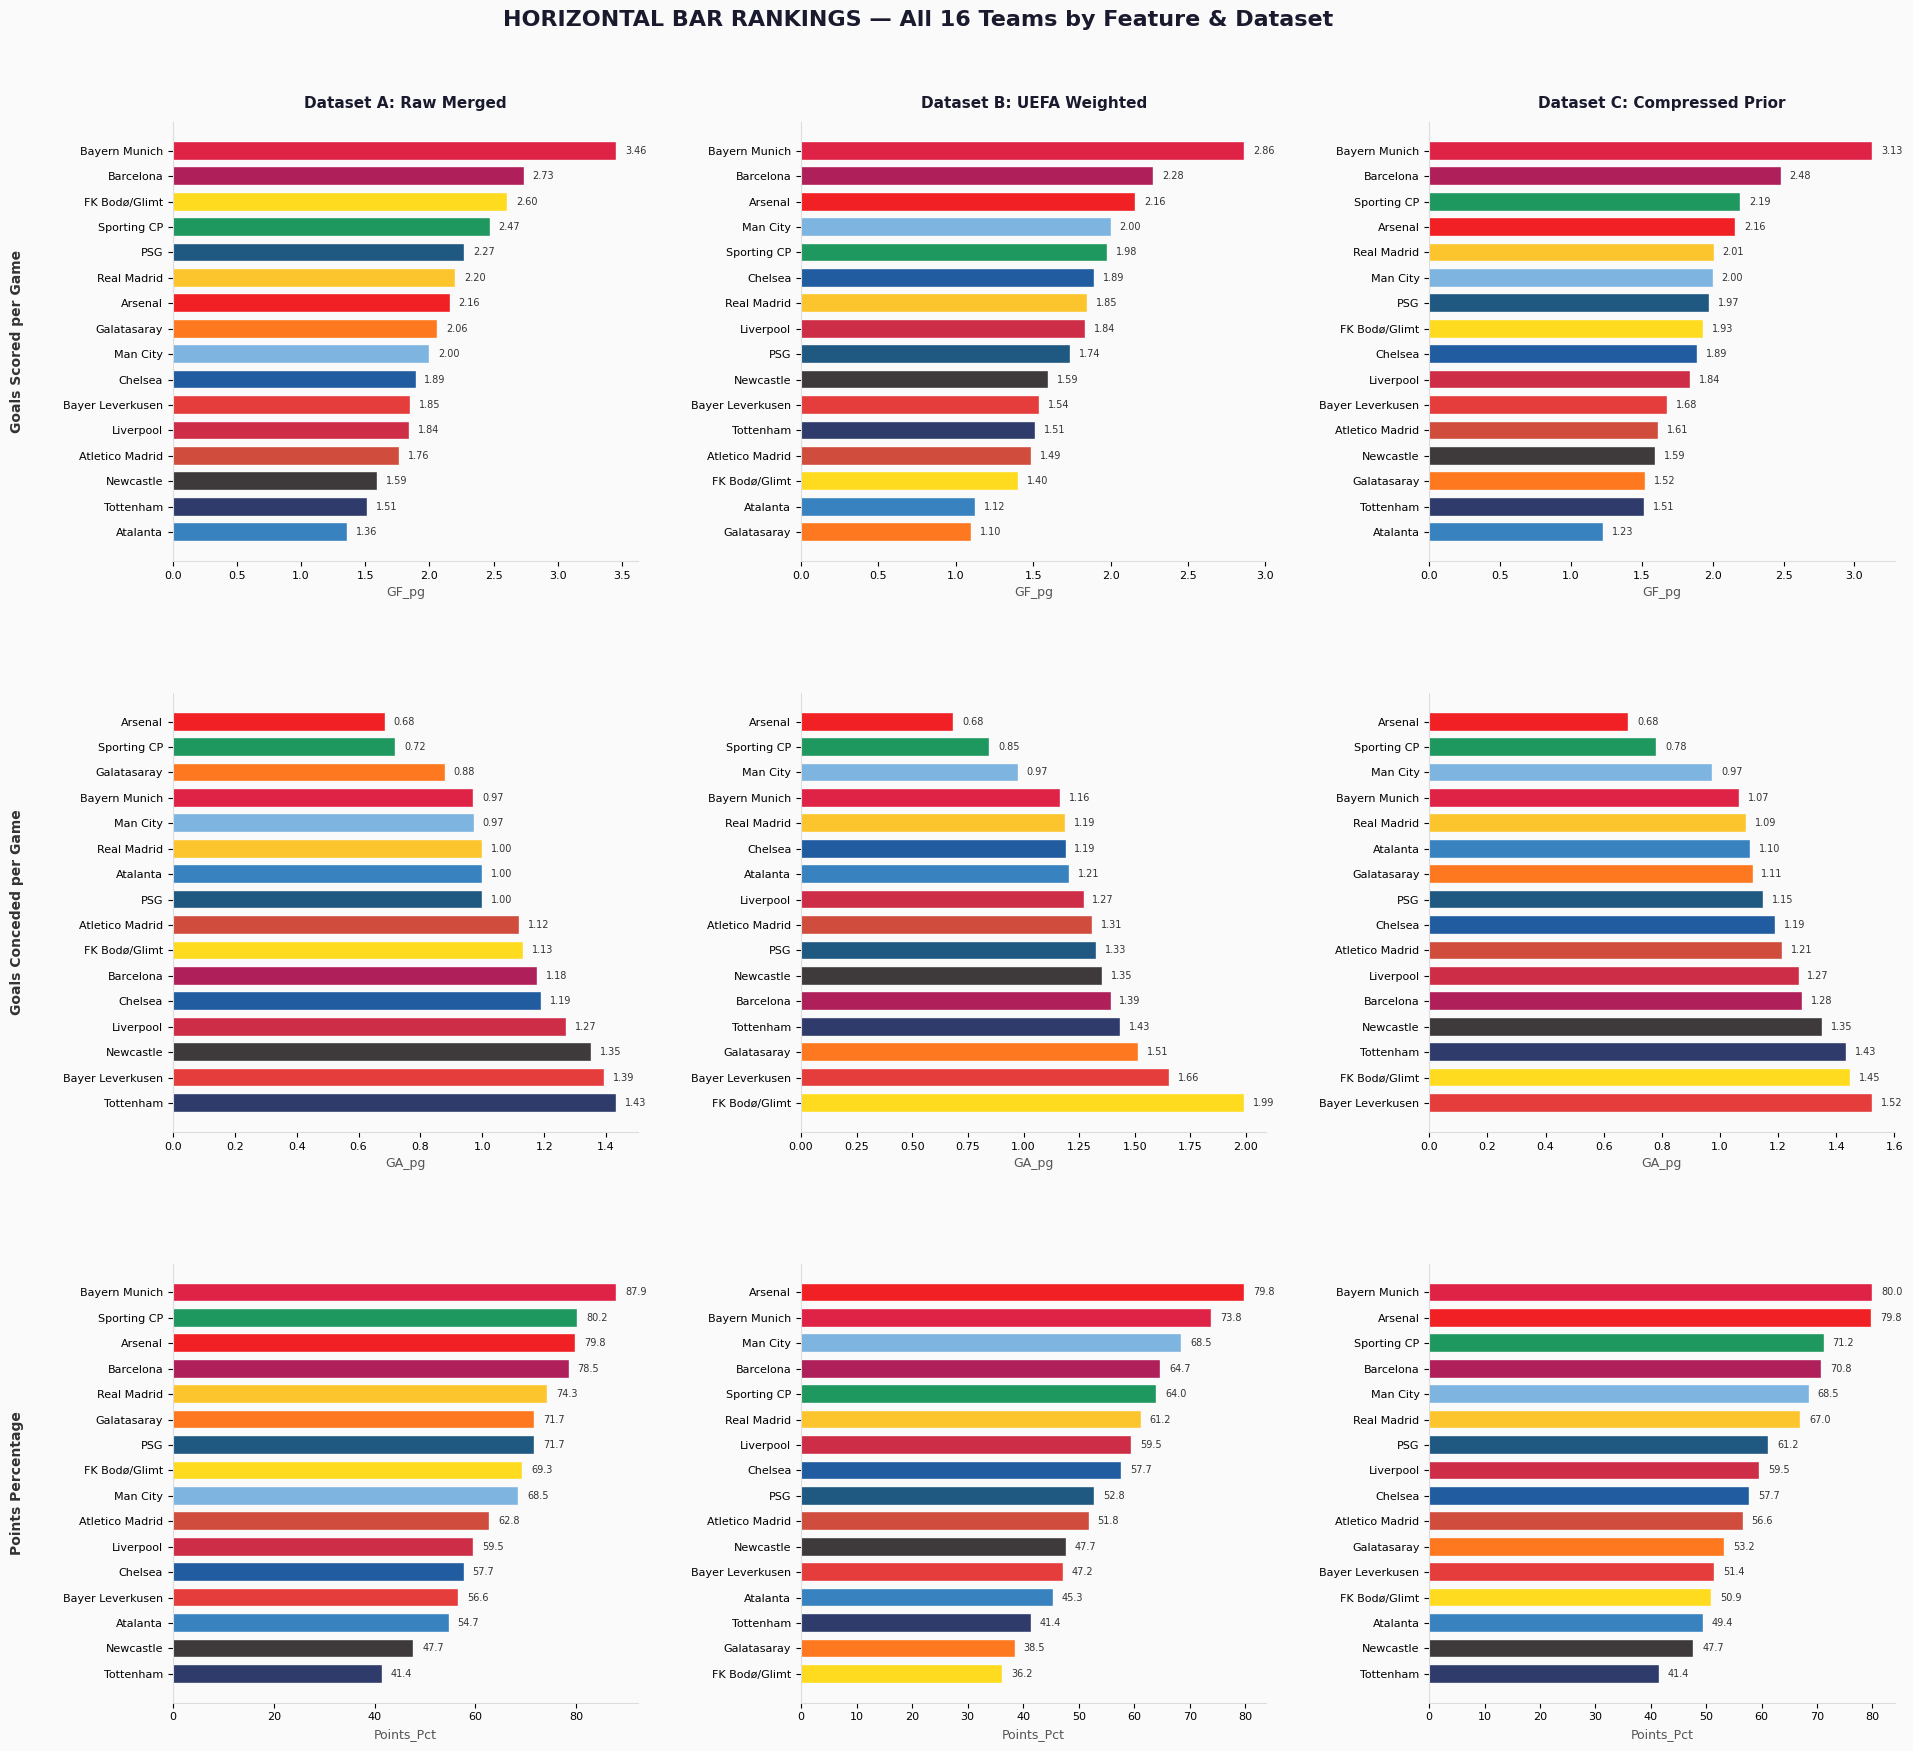

In [7]:
# HORIZONTAL BAR RANKINGS (3 features × 3 datasets)
features = ['GF_pg', 'GA_pg', 'Points_Pct']
feature_labels = {
    'GF_pg': 'Goals Scored per Game',
    'GA_pg': 'Goals Conceded per Game',
    'Points_Pct': 'Points Percentage'
}
sort_ascending = {'GF_pg': True, 'GA_pg': False, 'Points_Pct': True}

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('HORIZONTAL BAR RANKINGS — All 16 Teams by Feature & Dataset',
             fontsize=16, fontweight='bold', y=0.98, color='#1a1a2e')
fig.patch.set_facecolor('#FAFAFA')

for col, (ds_name, ds_df) in enumerate(datasets.items()):
    for row, feat in enumerate(features):
        ax = axes[row, col]
        sorted_df = ds_df.sort_values(feat, ascending=sort_ascending[feat])
        colors = [team_colors[t] for t in sorted_df.index]

        bars = ax.barh(range(len(sorted_df)), sorted_df[feat], color=colors, alpha=0.88, height=0.7,
                       edgecolor='white', linewidth=0.3)
        ax.set_yticks(range(len(sorted_df)))
        ax.set_yticklabels(sorted_df.index, fontsize=8, fontweight='500')
        ax.set_xlabel(feat, fontsize=9, color='#555')
        ax.tick_params(axis='x', labelsize=8)
        ax.set_facecolor('#FAFAFA')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#ddd')
        ax.spines['bottom'].set_color('#ddd')

        for i, (val, bar) in enumerate(zip(sorted_df[feat], bars)):
            ax.text(val + (sorted_df[feat].max() * 0.02), i,
                    f'{val:.2f}' if feat != 'Points_Pct' else f'{val:.1f}',
                    va='center', fontsize=7, color='#333')

        if row == 0:
            ax.set_title(f'Dataset {ds_name}', fontsize=11, fontweight='bold', pad=10, color='#1a1a2e')
        if col == 0:
            ax.annotate(feature_labels[feat], xy=(-0.35, 0.5), xycoords='axes fraction',
                       fontsize=10, fontweight='bold', rotation=90, va='center', color='#333')

plt.tight_layout(rect=[0.04, 0.01, 1, 0.96])
plt.subplots_adjust(hspace=0.3, wspace=0.35)
plt.show()

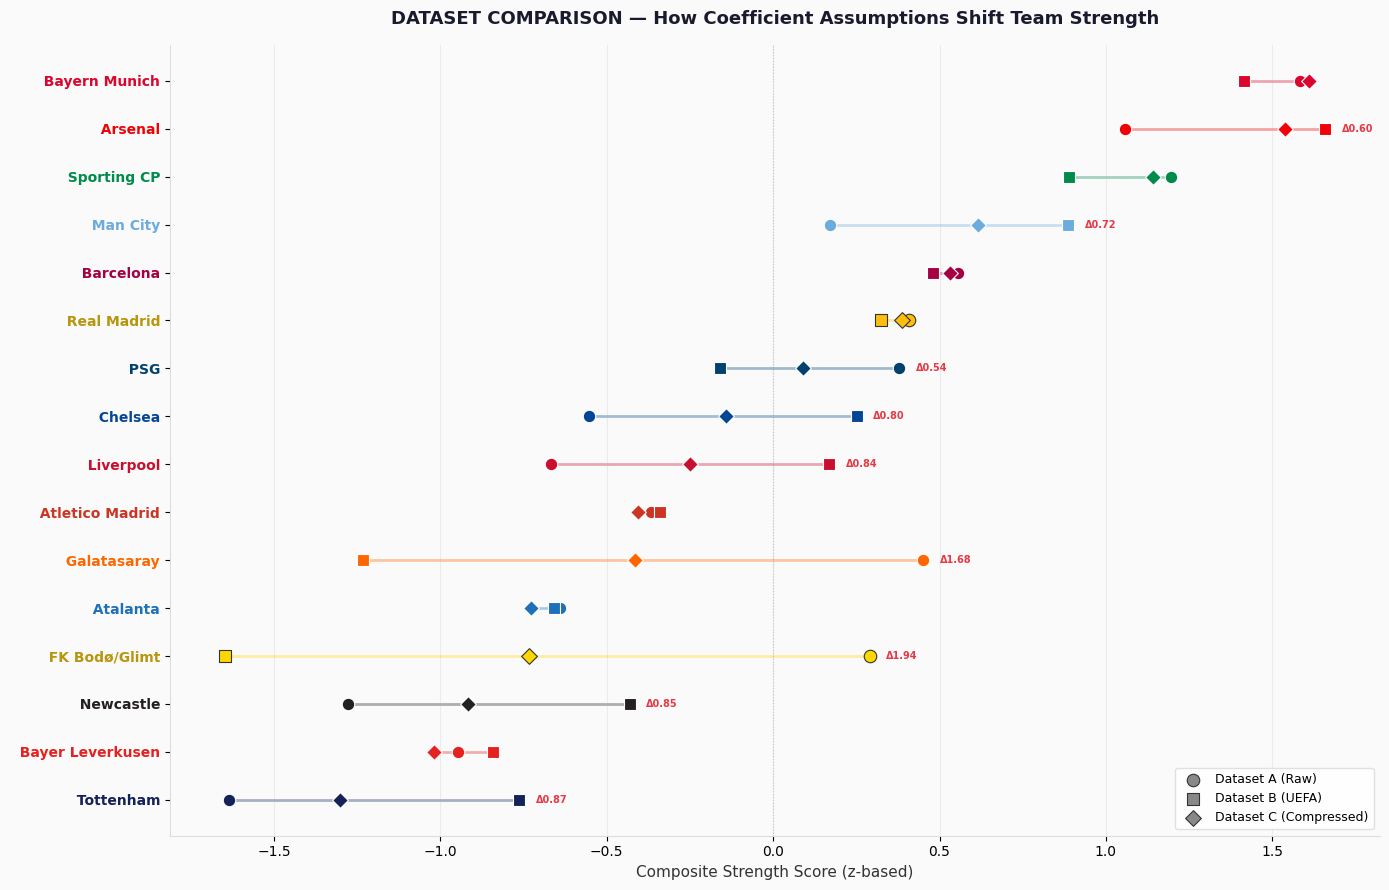


── SENSITIVITY SUMMARY ──

Most sensitive (largest spread across datasets):
Team
FK Bodø/Glimt    1.9378
Galatasaray      1.6843
Tottenham        0.8740
Newcastle        0.8461
Liverpool        0.8363

Most stable (smallest spread):
Team
Atletico Madrid     0.0665
Barcelona           0.0745
Real Madrid         0.0846
Atalanta            0.0847
Bayer Leverkusen    0.1783


In [9]:
# DATASET COMPARISON STRIP PLOT (team colors)

def compute_strength(df, w_gf=0.30, w_ga=0.35, w_pct=0.35):
    z = pd.DataFrame(index=df.index)
    z['z_GF'] = zscore(df['GF_pg'])
    z['z_GA'] = zscore(df['GA_pg'])
    z['z_Pct'] = zscore(df['Points_Pct'])
    return (w_gf * z['z_GF'] + w_ga * (-z['z_GA']) + w_pct * z['z_Pct']).round(4)

strength_A = compute_strength(dataset_A)
strength_B = compute_strength(dataset_B)
strength_C = compute_strength(dataset_C)

strip = pd.DataFrame({'A': strength_A, 'B': strength_B, 'C': strength_C})
strip['avg'] = strip.mean(axis=1)
strip = strip.sort_values('avg', ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

y_pos = range(len(strip))
ds_shapes = {'A': ('o', 9), 'B': ('s', 8), 'C': ('D', 8)}
ds_labels = {'A': 'Dataset A (Raw)', 'B': 'Dataset B (UEFA)', 'C': 'Dataset C (Compressed)'}

for team_idx, (team, row) in enumerate(strip.iterrows()):
    vals = [row['A'], row['B'], row['C']]
    # Connecting line in team color
    ax.plot([min(vals), max(vals)], [team_idx, team_idx],
            color=team_colors[team], linewidth=2, alpha=0.35, zorder=1)

    spread = max(vals) - min(vals)
    if spread > 0.5:
        ax.annotate(f'Δ{spread:.2f}', xy=(max(vals) + 0.05, team_idx),
                   fontsize=7, color='#E63946', fontweight='bold', va='center')

# Plot each dataset marker in team colors
for ds_key, (marker, size) in ds_shapes.items():
    for team_idx, (team, row) in enumerate(strip.iterrows()):
        edge = '#FFFFFF' if team_colors[team] not in ['#FFD700', '#FEBE10', '#FFFFFF'] else '#333333'
        ax.scatter(row[ds_key], team_idx, marker=marker, s=size**2,
                  color=team_colors[team], zorder=3,
                  edgecolors=edge, linewidths=0.8)

# Invisible legend entries for dataset shapes
for ds_key, (marker, size) in ds_shapes.items():
    ax.scatter([], [], marker=marker, s=size**2, color='#888',
              edgecolors='#333', linewidths=0.8, label=ds_labels[ds_key])

ax.set_yticks(y_pos)
ax.set_yticklabels([f'  {t}' for t in strip.index], fontsize=10, fontweight='600')
# Color each y-tick label
for tick_label, team in zip(ax.get_yticklabels(), strip.index):
    c = team_colors[team]
    if c in ['#FFD700', '#FEBE10']:
        c = '#B8960C'  # darken yellow for readability
    elif c in ['#FFFFFF']:
        c = '#555555'
    tick_label.set_color(c)

ax.set_xlabel('Composite Strength Score (z-based)', fontsize=11, color='#333')
ax.set_title('DATASET COMPARISON — How Coefficient Assumptions Shift Team Strength',
            fontsize=13, fontweight='bold', color='#1a1a2e', pad=15)
ax.axvline(0, color='#999', linewidth=0.8, linestyle=':', alpha=0.5)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9, edgecolor='#ddd')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ddd')
ax.spines['bottom'].set_color('#ddd')
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

print("\n── SENSITIVITY SUMMARY ──")
strip['spread'] = strip[['A','B','C']].max(axis=1) - strip[['A','B','C']].min(axis=1)
print("\nMost sensitive (largest spread across datasets):")
print(strip['spread'].sort_values(ascending=False).head(5).to_string())
print("\nMost stable (smallest spread):")
print(strip['spread'].sort_values(ascending=True).head(5).to_string())

**STRENGTH SCORING & BRACKET PREDICTION**

In [12]:
import numpy as np
import pandas as pd

# ============================================================
# EXPLORING DATA-DRIVEN FLOOR METHODS
# ============================================================

datasets_dict = {'A': dataset_A, 'B': dataset_B, 'C': dataset_C}
features = ['GF_pg', 'GA_pg', 'Points_Pct']

print("="*75)
print("  RAW FEATURE STATS — What the data tells us about spacing")
print("="*75)

for label, ds in datasets_dict.items():
    print(f"\n  Dataset {label}:")
    print(f"  {'Feature':<14s} {'Min':>7s} {'Max':>7s} {'Mean':>7s} {'Median':>7s} {'Std':>7s} {'Min/Max':>8s}")
    print(f"  {'─'*58}")
    for f in features:
        mn, mx = ds[f].min(), ds[f].max()
        mean, med, std = ds[f].mean(), ds[f].median(), ds[f].std()
        print(f"  {f:<14s} {mn:7.3f} {mx:7.3f} {mean:7.3f} {med:7.3f} {std:7.3f} {mn/mx:8.3f}")

print("\n  Min/Max ratio = natural floor if we just divide by max")
print("  This tells you how far behind the worst team truly is")

  RAW FEATURE STATS — What the data tells us about spacing

  Dataset A:
  Feature            Min     Max    Mean  Median     Std  Min/Max
  ──────────────────────────────────────────────────────────
  GF_pg            1.361   3.455   2.111   2.030   0.524    0.394
  GA_pg            0.684   1.432   1.080   1.059   0.220    0.478
  Points_Pct      41.400  87.900  66.394  68.900  12.790    0.471

  Dataset B:
  Feature            Min     Max    Mean  Median     Std  Min/Max
  ──────────────────────────────────────────────────────────
  GF_pg            1.097   2.864   1.771   1.787   0.445    0.383
  GA_pg            0.684   1.992   1.281   1.289   0.308    0.343
  Points_Pct      36.200  79.800  55.631  55.250  12.700    0.454

  Dataset C:
  Feature            Min     Max    Mean  Median     Std  Min/Max
  ──────────────────────────────────────────────────────────
  GF_pg            1.228   3.127   1.922   1.913   0.446    0.393
  GA_pg            0.684   1.524   1.167   1.168   0.228

In [13]:
# ============================================================
# METHOD COMPARISON — 5 approaches to normalization
# ============================================================

def method_proportion_of_max(df):
    """Simply divide by max. Floor emerges naturally from data."""
    normed = pd.DataFrame(index=df.index)
    for col in features:
        normed[col] = (df[col] / df[col].max()).round(4)
    return normed

def method_arbitrary_floor(df, floor=0.10):
    """Standard min-max mapped to [floor, 1.0]. Arbitrary."""
    normed = pd.DataFrame(index=df.index)
    for col in features:
        mn, mx = df[col].min(), df[col].max()
        normed[col] = (floor + (1 - floor) * (df[col] - mn) / (mx - mn)).round(4)
    return normed

def method_mean_anchored(df):
    """Floor = min/mean for each feature. Data-driven per feature."""
    normed = pd.DataFrame(index=df.index)
    for col in features:
        mn, mx, mean = df[col].min(), df[col].max(), df[col].mean()
        floor = mn / mean  # how far worst is from average
        normed[col] = (floor + (1 - floor) * (df[col] - mn) / (mx - mn)).round(4)
    return normed

def method_log_transform(df):
    """Log-transform then min-max to [0,1]. Compresses top, lifts bottom."""
    normed = pd.DataFrame(index=df.index)
    for col in features:
        logged = np.log1p(df[col])  # log(1+x) to handle small values
        mn, mx = logged.min(), logged.max()
        normed[col] = ((logged - mn) / (mx - mn)).round(4)
    return normed

def method_median_std_floor(df):
    """Floor = (median - 1*std) / max, clamped to [0.05, 0.5]. Statistical."""
    normed = pd.DataFrame(index=df.index)
    for col in features:
        mn, mx = df[col].min(), df[col].max()
        med, std = df[col].median(), df[col].std()
        floor = max(0.05, min(0.5, (med - std) / mx))
        normed[col] = (floor + (1 - floor) * (df[col] - mn) / (mx - mn)).round(4)
    return normed

# ── Apply all methods to Dataset A and compare Tottenham + Arsenal ──
methods = {
    '1. Proportion of Max':    method_proportion_of_max,
    '2. Arbitrary Floor=0.10': lambda df: method_arbitrary_floor(df, 0.10),
    '3. Mean-Anchored Floor':  method_mean_anchored,
    '4. Log-Transform':        method_log_transform,
    '5. Median−1σ Floor':      method_median_std_floor,
}

spotlight = ['Arsenal', 'Bayern Munich', 'Tottenham', 'FK Bodø/Glimt', 'Newcastle']

print("="*80)
print("  NORMALIZATION METHOD COMPARISON — Dataset A, Key Teams")
print("="*80)

for method_name, method_fn in methods.items():
    normed = method_fn(dataset_A)
    print(f"\n  {method_name}")
    print(f"  {'Team':<22s} {'GF':>8s} {'GA':>8s} {'Pct':>8s}")
    print(f"  {'─'*48}")
    for team in spotlight:
        print(f"  {team:<22s} {normed.loc[team, 'GF_pg']:8.3f} "
              f"{normed.loc[team, 'GA_pg']:8.3f} {normed.loc[team, 'Points_Pct']:8.3f}")

    # Show floor and range
    mins = {col: normed[col].min() for col in features}
    print(f"  → Effective floors: GF={mins['GF_pg']:.3f}  GA={mins['GA_pg']:.3f}  Pct={mins['Points_Pct']:.3f}")

  NORMALIZATION METHOD COMPARISON — Dataset A, Key Teams

  1. Proportion of Max
  Team                         GF       GA      Pct
  ────────────────────────────────────────────────
  Arsenal                   0.625    0.478    0.908
  Bayern Munich             1.000    0.677    1.000
  Tottenham                 0.438    1.000    0.471
  FK Bodø/Glimt             0.754    0.790    0.788
  Newcastle                 0.462    0.943    0.543
  → Effective floors: GF=0.394  GA=0.478  Pct=0.471

  2. Arbitrary Floor=0.10
  Team                         GF       GA      Pct
  ────────────────────────────────────────────────
  Arsenal                   0.443    0.100    0.843
  Bayern Munich             1.000    0.444    1.000
  Tottenham                 0.166    1.000    0.100
  FK Bodø/Glimt             0.635    0.639    0.640
  Newcastle                 0.201    0.902    0.222
  → Effective floors: GF=0.100  GA=0.100  Pct=0.100

  3. Mean-Anchored Floor
  Team                         GF   

In [15]:
# ============================================================
# STRENGTH SCORE COMPARISON — How each method affects the gap
# ============================================================

print("="*80)
print("  STRENGTH SCORES BY METHOD — Full ranking + gap analysis")
print("="*80)

def compute_strength(normed_df, w_gf=0.30, w_ga=0.35, w_pct=0.35):
    s = pd.DataFrame(index=normed_df.index)
    s['Strength'] = (w_gf * normed_df['GF_pg'] +
                     w_ga * (1 - normed_df['GA_pg']) +
                     w_pct * normed_df['Points_Pct']).round(4)
    return s['Strength']

method_strengths = {}
for method_name, method_fn in methods.items():
    normed = method_fn(dataset_A)
    s = compute_strength(normed)
    method_strengths[method_name] = s

    ranked = s.sort_values(ascending=False)
    gap = s.max() - s.min()
    std = s.std()

    # Win prob for biggest gap
    p_max = 1 / (1 + np.exp(-1.5 * gap))
    # Win prob for median gap (8th vs 9th)
    sorted_vals = s.sort_values(ascending=False).values
    med_gap = sorted_vals[3] - sorted_vals[4]  # 4th vs 5th
    p_med = 1 / (1 + np.exp(-1.5 * med_gap))

    print(f"\n  {method_name}")
    print(f"  Range: {gap:.3f}  |  Std: {std:.3f}  |  "
          f"Max matchup P: {p_max*100:.0f}%  |  Mid-table matchup P: {p_med*100:.0f}%")
    print(f"  Top 3: {', '.join(f'{t} ({v:.3f})' for t, v in ranked.head(3).items())}")
    print(f"  Bot 3: {', '.join(f'{t} ({v:.3f})' for t, v in ranked.tail(3).items())}")

# ── Summary table ──
print(f"\n{'='*80}")
print("  VERDICT — Which method produces the most balanced competition?")
print(f"{'='*80}")
print(f"\n  {'Method':<28s} {'Range':>7s} {'Std':>7s} {'Max P%':>7s} {'Mid P%':>7s} {'Realism':>10s}")
print(f"  {'─'*68}")

for method_name, s in method_strengths.items():
    gap = s.max() - s.min()
    std = s.std()
    p_max = 1 / (1 + np.exp(-1.5 * gap)) * 100
    sorted_vals = s.sort_values(ascending=False).values
    med_gap = sorted_vals[3] - sorted_vals[4]
    p_med = 1 / (1 + np.exp(-1.5 * med_gap)) * 100

    # Realism score: max matchup shouldn't exceed ~75%, mid shouldn't exceed ~60%
    if p_max <= 75 and p_med <= 60:
        realism = '✅ IDEAL'
    elif p_max <= 82 and p_med <= 65:
        realism = '⚠️ OK'
    else:
        realism = '❌ TOO WIDE'

    short_name = method_name[:27]
    print(f"  {short_name:<28s} {gap:7.3f} {std:7.3f} {p_max:6.1f}% {p_med:6.1f}% {realism:>10s}")



  STRENGTH SCORES BY METHOD — Full ranking + gap analysis

  1. Proportion of Max
  Range: 0.467  |  Std: 0.133  |  Max matchup P: 67%  |  Mid-table matchup P: 50%
  Top 3: Bayern Munich (0.763), Sporting CP (0.708), Arsenal (0.688)
  Bot 3: Bayer Leverkusen (0.395), Newcastle (0.348), Tottenham (0.296)

  2. Arbitrary Floor=0.10
  Range: 0.760  |  Std: 0.218  |  Max matchup P: 76%  |  Mid-table matchup P: 50%
  Top 3: Bayern Munich (0.845), Sporting CP (0.771), Arsenal (0.743)
  Bot 3: Bayer Leverkusen (0.247), Newcastle (0.172), Tottenham (0.085)

  3. Mean-Anchored Floor
  Range: 0.310  |  Std: 0.089  |  Max matchup P: 61%  |  Mid-table matchup P: 50%
  Top 3: Bayern Munich (0.729), Sporting CP (0.701), Arsenal (0.690)
  Bot 3: Bayer Leverkusen (0.486), Newcastle (0.455), Tottenham (0.419)

  4. Log-Transform
  Range: 0.821  |  Std: 0.241  |  Max matchup P: 77%  |  Mid-table matchup P: 50%
  Top 3: Bayern Munich (0.851), Sporting CP (0.819), Arsenal (0.792)
  Bot 3: Bayer Leverkusen

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# SETUP
# ============================================================
team_colors = {
    'Arsenal': '#EF0107', 'Man City': '#6CABDD', 'Chelsea': '#034694',
    'Liverpool': '#C8102E', 'Newcastle': '#241F20', 'Tottenham': '#132257',
    'Barcelona': '#A50044', 'Real Madrid': '#FEBE10', 'Atletico Madrid': '#CB3524',
    'Atalanta': '#1E71B8', 'Galatasaray': '#FF6600', 'Bayern Munich': '#DC052D',
    'Bayer Leverkusen': '#E32221', 'FK Bodø/Glimt': '#FFD700',
    'Sporting CP': '#008B4A', 'PSG': '#004170',
}

names = {'A': 'Raw Merged', 'B': 'UEFA Weighted', 'C': 'Compressed Prior'}
datasets_dict = {'A': dataset_A, 'B': dataset_B, 'C': dataset_C}
features = ['GF_pg', 'GA_pg', 'Points_Pct']

# ============================================================
# METHOD 5: MEDIAN − 1σ FLOOR NORMALIZATION
# ============================================================

def median_std_floor_normalize(df):
    """
    Floor = (median - 1*std) / max, clamped to [0.05, 0.5].
    Then min-max scale to [floor, 1.0] per feature.
    """
    normed = pd.DataFrame(index=df.index)
    floors = {}
    for col in features:
        mn, mx = df[col].min(), df[col].max()
        med, std = df[col].median(), df[col].std()
        floor = max(0.05, min(0.5, (med - std) / mx))
        floors[col] = round(floor, 3)
        normed[col] = (floor + (1 - floor) * (df[col] - mn) / (mx - mn)).round(4)
    return normed, floors

# ── Normalize all 3 datasets ──
normalized = {}
all_floors = {}
for label, ds in datasets_dict.items():
    normalized[label], all_floors[label] = median_std_floor_normalize(ds)

print("="*70)
print("  MEDIAN−1σ FLOOR NORMALIZATION — Applied to All 3 Datasets")
print("="*70)

for label in ['A', 'B', 'C']:
    f = all_floors[label]
    print(f"\n  Dataset {label} ({names[label]}):")
    print(f"    Computed floors → GF: {f['GF_pg']}  GA: {f['GA_pg']}  Pct: {f['Points_Pct']}")
    print(f"    Range: [{f['GF_pg']:.2f}–1.00], [{f['GA_pg']:.2f}–1.00], [{f['Points_Pct']:.2f}–1.00]")

# ── Show normalized values for Dataset A ──
print(f"\n{'='*70}")
print("  NORMALIZED VALUES — Dataset A (sorted by Points_Pct)")
print(f"{'='*70}")
display = normalized['A'].sort_values('Points_Pct', ascending=False)
print(display.round(3).to_string())
print(f"\n  ✓ Tottenham Pct = {normalized['A'].loc['Tottenham', 'Points_Pct']:.3f} (data-driven floor, not 0)")

  MEDIAN−1σ FLOOR NORMALIZATION — Applied to All 3 Datasets

  Dataset A (Raw Merged):
    Computed floors → GF: 0.436  GA: 0.5  Pct: 0.5
    Range: [0.44–1.00], [0.50–1.00], [0.50–1.00]

  Dataset B (UEFA Weighted):
    Computed floors → GF: 0.469  GA: 0.493  Pct: 0.5
    Range: [0.47–1.00], [0.49–1.00], [0.50–1.00]

  Dataset C (Compressed Prior):
    Computed floors → GF: 0.469  GA: 0.5  Pct: 0.5
    Range: [0.47–1.00], [0.50–1.00], [0.50–1.00]

  NORMALIZED VALUES — Dataset A (sorted by Points_Pct)
                  GF_pg  GA_pg  Points_Pct
Team                                      
Bayern Munich     1.000  0.691       1.000
Sporting CP       0.734  0.523       0.917
Arsenal           0.651  0.500       0.913
Barcelona         0.806  0.829       0.899
Real Madrid       0.662  0.711       0.854
PSG               0.682  0.711       0.826
Galatasaray       0.625  0.630       0.826
FK Bodø/Glimt     0.771  0.800       0.800
Man City          0.608  0.693       0.791
Atletico Madrid   0

In [17]:
# ============================================================
# STRENGTH SCORES
# ============================================================

def compute_strength(normed_df, w_gf=0.30, w_ga=0.35, w_pct=0.35):
    z = pd.DataFrame(index=normed_df.index)
    z['GF']  = normed_df['GF_pg']
    z['GA']  = 1 - normed_df['GA_pg']  # flip: low conceding → high score
    z['Pct'] = normed_df['Points_Pct']
    z['Strength'] = (w_gf * z['GF'] + w_ga * z['GA'] + w_pct * z['Pct']).round(4)
    return z

strength = {}
for label in ['A', 'B', 'C']:
    strength[label] = compute_strength(normalized[label])

for label in ['A', 'B', 'C']:
    print(f"\n{'='*60}")
    print(f"  DATASET {label} — {names[label]} — STRENGTH (Median−1σ)")
    print(f"{'='*60}")
    display = strength[label].sort_values('Strength', ascending=False)
    print(display.round(3).to_string())

print(f"\n{'='*60}")
print("  STRENGTH RANGE & WIN PROBABILITY CHECK")
print(f"{'='*60}")
for label in ['A', 'B', 'C']:
    s = strength[label]['Strength']
    gap = s.max() - s.min()
    sorted_v = s.sort_values(ascending=False).values
    mid_gap = sorted_v[3] - sorted_v[4]
    p_max = 1 / (1 + np.exp(-1.5 * gap)) * 100
    p_mid = 1 / (1 + np.exp(-1.5 * mid_gap)) * 100
    print(f"  DS {label}: range={gap:.3f}  std={s.std():.3f}  "
          f"Max P={p_max:.0f}%  Mid P={p_mid:.0f}%")


  DATASET A — Raw Merged — STRENGTH (Median−1σ)
                     GF     GA    Pct  Strength
Team                                           
Bayern Munich     1.000  0.309  1.000     0.758
Sporting CP       0.734  0.477  0.917     0.708
Arsenal           0.651  0.500  0.913     0.690
Barcelona         0.806  0.171  0.899     0.616
Galatasaray       0.625  0.370  0.826     0.606
Real Madrid       0.662  0.289  0.854     0.598
PSG               0.682  0.289  0.826     0.595
FK Bodø/Glimt     0.771  0.200  0.800     0.582
Man City          0.608  0.307  0.791     0.567
Atletico Madrid   0.545  0.210  0.730     0.492
Chelsea           0.579  0.162  0.675     0.467
Atalanta          0.436  0.289  0.643     0.457
Liverpool         0.564  0.108  0.695     0.450
Bayer Leverkusen  0.567  0.025  0.663     0.411
Newcastle         0.499  0.054  0.568     0.367
Tottenham         0.477  0.000  0.500     0.318

  DATASET B — UEFA Weighted — STRENGTH (Median−1σ)
                     GF     GA    P

In [18]:
# ============================================================
# PROBABILISTIC SIMULATION — 10,000 runs
# ============================================================

N_SIMS = 10_000
np.random.seed(42)

bracket_ties = {
    'R16': [
        ('PSG', 'Chelsea'),
        ('Galatasaray', 'Liverpool'),
        ('Real Madrid', 'Man City'),
        ('Atalanta', 'Bayern Munich'),
        ('Newcastle', 'Barcelona'),
        ('Atletico Madrid', 'Tottenham'),
        ('FK Bodø/Glimt', 'Sporting CP'),
        ('Bayer Leverkusen', 'Arsenal'),
    ],
    'QF_pairs': [(0,1), (2,3), (4,5), (6,7)],
    'SF_pairs': [(0,1), (2,3)],
}

def win_prob(s_a, s_b, k=1.5):
    return 1 / (1 + np.exp(-k * (s_a - s_b)))

def simulate_bracket(strength_series, n_sims=N_SIMS, k=1.5):
    s = strength_series
    round_counts = {rnd: defaultdict(int) for rnd in ['R16', 'QF', 'SF', 'Final', 'Champion']}
    matchup_wins = defaultdict(lambda: defaultdict(int))

    for _ in range(n_sims):
        r16_winners = []
        for team_a, team_b in bracket_ties['R16']:
            p_a = win_prob(s[team_a], s[team_b], k)
            winner = team_a if np.random.random() < p_a else team_b
            r16_winners.append(winner)
            round_counts['R16'][winner] += 1
            matchup_wins[(team_a, team_b)][winner] += 1

        qf_winners = []
        for idx_a, idx_b in bracket_ties['QF_pairs']:
            team_a, team_b = r16_winners[idx_a], r16_winners[idx_b]
            p_a = win_prob(s[team_a], s[team_b], k)
            winner = team_a if np.random.random() < p_a else team_b
            qf_winners.append(winner)
            round_counts['QF'][winner] += 1

        sf_winners = []
        for idx_a, idx_b in bracket_ties['SF_pairs']:
            team_a, team_b = qf_winners[idx_a], qf_winners[idx_b]
            p_a = win_prob(s[team_a], s[team_b], k)
            winner = team_a if np.random.random() < p_a else team_b
            sf_winners.append(winner)
            round_counts['SF'][winner] += 1

        team_a, team_b = sf_winners[0], sf_winners[1]
        p_a = win_prob(s[team_a], s[team_b], k)
        winner = team_a if np.random.random() < p_a else team_b
        round_counts['Final'][winner] += 1
        round_counts['Champion'][winner] += 1

    return round_counts, matchup_wins

sim_results = {}
sim_matchups = {}

for label in ['A', 'B', 'C']:
    sim_results[label], sim_matchups[label] = simulate_bracket(strength[label]['Strength'])
    print(f"✓ Dataset {label} ({names[label]}): {N_SIMS:,} simulations complete")

print(f"\nTotal: {N_SIMS * 3:,} bracket simulations")

✓ Dataset A (Raw Merged): 10,000 simulations complete
✓ Dataset B (UEFA Weighted): 10,000 simulations complete
✓ Dataset C (Compressed Prior): 10,000 simulations complete

Total: 30,000 bracket simulations


In [19]:
# ============================================================
# TOURNAMENT WIN PROBABILITIES
# ============================================================

print("="*75)
print(f"  🏆 TOURNAMENT WIN PROBABILITY — Median−1σ Floor ({N_SIMS:,} sims)")
print("="*75)

champ_data = {}
for label in ['A', 'B', 'C']:
    champ_data[label] = {team: count / N_SIMS * 100
                         for team, count in sim_results[label]['Champion'].items()}

champ_df = pd.DataFrame(champ_data).fillna(0).round(2)
champ_df.columns = [f'DS_{l} (%)' for l in ['A', 'B', 'C']]
champ_df['Average (%)'] = champ_df.mean(axis=1).round(2)
champ_df = champ_df.sort_values('Average (%)', ascending=False)

print(champ_df.to_string())

for label in ['A', 'B', 'C']:
    col = f'DS_{label} (%)'
    top = champ_df[col].idxmax()
    pct = champ_df.loc[top, col]
    print(f"\n  Dataset {label} favorite: {top} ({pct:.1f}%)")

avg_top = champ_df['Average (%)'].idxmax()
avg_pct = champ_df.loc[avg_top, 'Average (%)']
print(f"\n  🏆 Overall favorite: {avg_top} ({avg_pct:.1f}%)")

  🏆 TOURNAMENT WIN PROBABILITY — Median−1σ Floor (10,000 sims)
                  DS_A (%)  DS_B (%)  DS_C (%)  Average (%)
Arsenal               9.51     11.97     11.91        11.13
Bayern Munich        11.52     10.46     10.48        10.82
Sporting CP           9.23      8.82      9.93         9.33
Barcelona             8.93      7.60      8.55         8.36
Man City              5.65      7.62      6.90         6.72
Real Madrid           6.65      6.57      6.11         6.44
PSG                   6.90      4.97      6.06         5.98
Atletico Madrid       5.99      5.69      5.60         5.76
Chelsea               4.62      6.91      5.44         5.66
Galatasaray           7.84      3.45      5.36         5.55
Liverpool             4.16      6.50      5.09         5.25
FK Bodø/Glimt         6.10      2.62      4.37         4.36
Newcastle             3.31      4.83      3.93         4.02
Atalanta              3.41      3.86      3.72         3.66
Bayer Leverkusen      3.45      3.74 

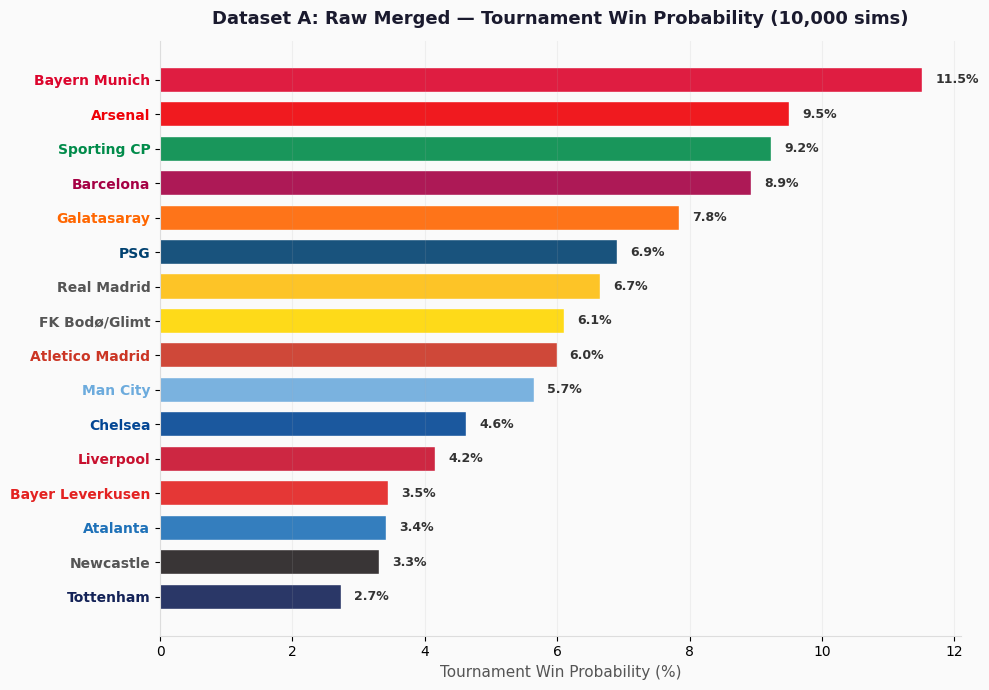

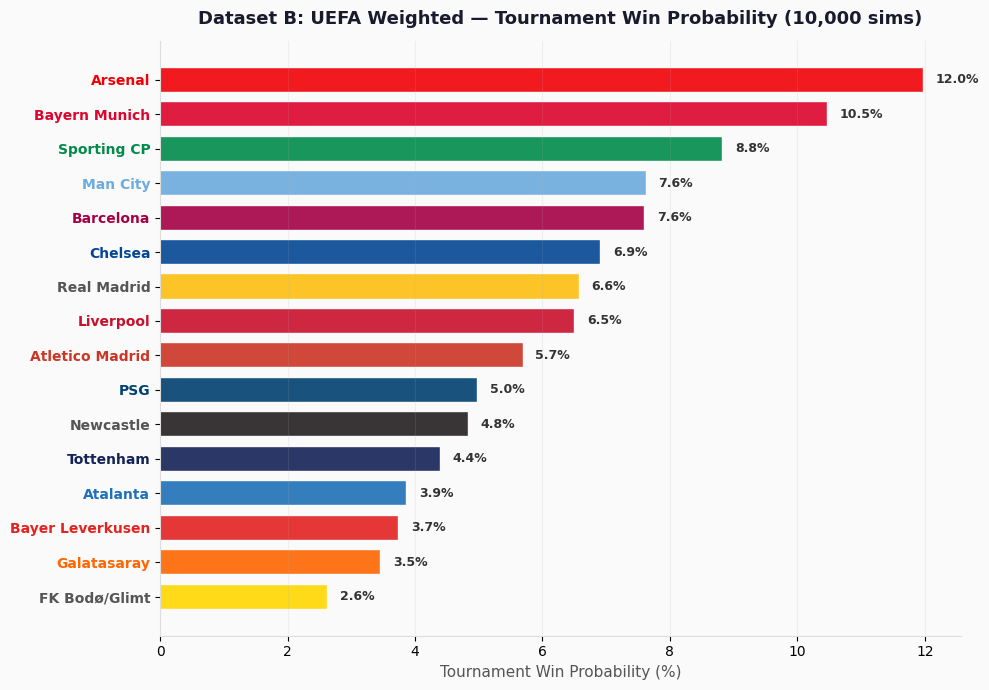

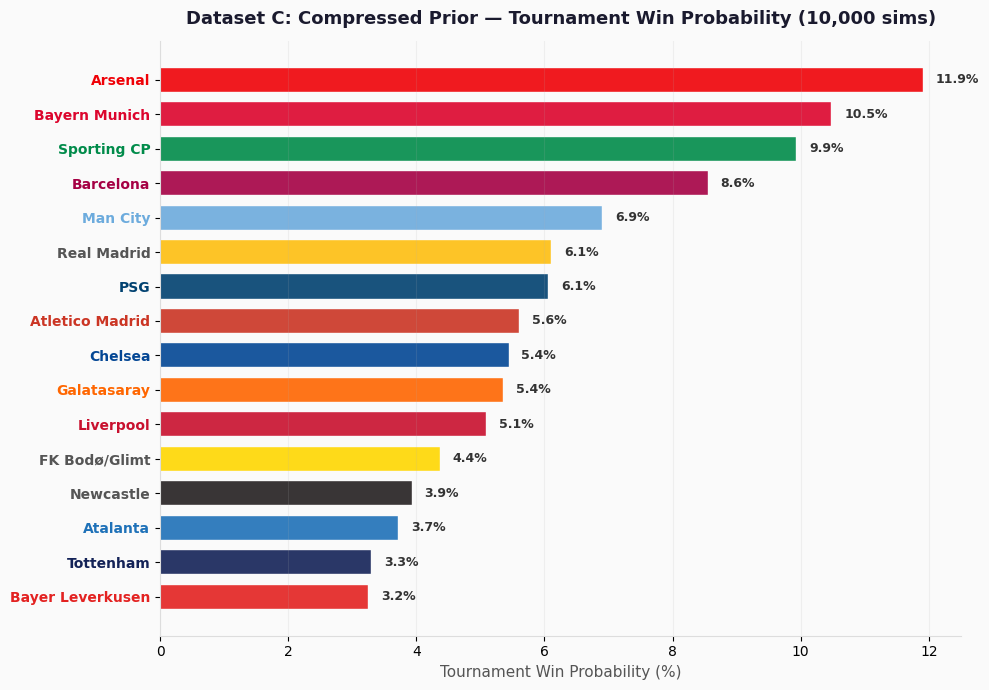

✓ 3 independent tournament win probability charts complete


In [22]:
# ============================================================
# CHART: TOURNAMENT WIN % — 3 SEPARATE CHARTS (correct y-labels)
# ============================================================

for label in ['A', 'B', 'C']:
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    # Get data and sort independently for this dataset
    data = {team: count / N_SIMS * 100
            for team, count in sim_results[label]['Champion'].items()}

    # Include all teams (even 0%)
    for team in team_colors.keys():
        if team not in data:
            data[team] = 0.0

    sorted_teams = sorted(data.keys(), key=lambda t: data[t])
    vals = [data[t] for t in sorted_teams]
    colors = [team_colors[t] for t in sorted_teams]

    bars = ax.barh(range(len(sorted_teams)), vals, color=colors, alpha=0.9,
                   height=0.7, edgecolor='white', linewidth=0.3)

    ax.set_yticks(range(len(sorted_teams)))
    ax.set_yticklabels(sorted_teams, fontsize=10, fontweight='600')

    # Color each y-label to match its team
    for tick, team in zip(ax.get_yticklabels(), sorted_teams):
        c = team_colors[team]
        if c in ['#FFD700', '#FEBE10', '#FFFFFF', '#241F20']:
            c = '#555'
        tick.set_color(c)

    # Value labels on bars
    for j, (val, bar) in enumerate(zip(vals, bars)):
        if val > 0.3:
            ax.text(val + 0.2, j, f'{val:.1f}%', va='center', fontsize=9,
                   fontweight='bold', color='#333')

    ax.set_xlabel('Tournament Win Probability (%)', fontsize=11, color='#555')
    ax.set_title(f'Dataset {label}: {names[label]} — Tournament Win Probability ({N_SIMS:,} sims)',
                fontsize=13, fontweight='bold', color='#1a1a2e', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#ddd')
    ax.spines['bottom'].set_color('#ddd')
    ax.grid(axis='x', alpha=0.15)

    plt.tight_layout()
    plt.show()

print("✓ 3 independent tournament win probability charts complete")

In [21]:
# ============================================================
# R16 MATCHUP WIN RATES
# ============================================================

print("="*75)
print(f"  R16 MATCHUP WIN RATES (Median−1σ) — {N_SIMS:,} sims")
print("="*75)

for team_a, team_b in bracket_ties['R16']:
    print(f"\n  {team_a} vs {team_b}")
    print(f"  {'─'*60}")

    for label in ['A', 'B', 'C']:
        key = (team_a, team_b)
        wins_a = sim_matchups[label][key].get(team_a, 0)
        wins_b = sim_matchups[label][key].get(team_b, 0)
        pct_a = wins_a / N_SIMS * 100
        pct_b = wins_b / N_SIMS * 100

        bar_a = '█' * int(pct_a / 5)
        bar_b = '█' * int(pct_b / 5)

        margin = abs(pct_a - pct_b)
        closeness = '🔥 TIGHT' if margin < 15 else '⚖️ LEAN' if margin < 35 else '💪 CLEAR'

        print(f"    DS {label}: {team_a:>20s} {pct_a:5.1f}% {bar_a}")
        print(f"          {team_b:>20s} {pct_b:5.1f}% {bar_b}  {closeness}")

print("\n" + "="*75)
print("  🔥 TIGHT = <15% gap  |  ⚖️ LEAN = 15-35% gap  |  💪 CLEAR = >35% gap")
print("="*75)

  R16 MATCHUP WIN RATES (Median−1σ) — 10,000 sims

  PSG vs Chelsea
  ────────────────────────────────────────────────────────────
    DS A:                  PSG  54.4% ██████████
                       Chelsea  45.6% █████████  🔥 TIGHT
    DS B:                  PSG  47.7% █████████
                       Chelsea  52.3% ██████████  🔥 TIGHT
    DS C:                  PSG  51.5% ██████████
                       Chelsea  48.5% █████████  🔥 TIGHT

  Galatasaray vs Liverpool
  ────────────────────────────────────────────────────────────
    DS A:          Galatasaray  56.5% ███████████
                     Liverpool  43.5% ████████  🔥 TIGHT
    DS B:          Galatasaray  43.4% ████████
                     Liverpool  56.6% ███████████  🔥 TIGHT
    DS C:          Galatasaray  49.6% █████████
                     Liverpool  50.4% ██████████  🔥 TIGHT

  Real Madrid vs Man City
  ────────────────────────────────────────────────────────────
    DS A:          Real Madrid  51.0% ██████████
   

In [24]:
# ============================================================
# ROUND-BY-ROUND ADVANCEMENT
# ============================================================

print("="*80)
print(f"  ROUND-BY-ROUND ADVANCEMENT (Median−1σ) — {N_SIMS:,} sims")
print("="*80)

for label in ['A', 'B', 'C']:
    print(f"\n  ── Dataset {label}: {names[label]} ──")
    print(f"  {'Team':<22s} {'R16 Win':>8s} {'QF Win':>8s} {'SF Win':>8s} {'Champion':>9s}")
    print(f"  {'─'*56}")

    all_teams_sorted = sorted(team_colors.keys(),
                              key=lambda t: sim_results[label]['Champion'].get(t, 0),
                              reverse=True)

    for team in all_teams_sorted:
        r16 = sim_results[label]['R16'].get(team, 0) / N_SIMS * 100
        qf  = sim_results[label]['QF'].get(team, 0) / N_SIMS * 100
        sf  = sim_results[label]['SF'].get(team, 0) / N_SIMS * 100
        chp = sim_results[label]['Champion'].get(team, 0) / N_SIMS * 100
        print(f"  {team:<22s} {r16:>7.1f}% {qf:>7.1f}% {sf:>7.1f}% {chp:>8.1f}%")

  ROUND-BY-ROUND ADVANCEMENT (Median−1σ) — 10,000 sims

  ── Dataset A: Raw Merged ──
  Team                    R16 Win   QF Win   SF Win  Champion
  ────────────────────────────────────────────────────────
  Bayern Munich             61.9%    34.8%    20.5%     11.5%
  Arsenal                   61.1%    31.2%    17.7%      9.5%
  Sporting CP               54.6%    30.0%    17.6%      9.2%
  Barcelona                 59.4%    34.1%    17.0%      8.9%
  Galatasaray               56.5%    29.7%    14.8%      7.8%
  PSG                       54.4%    28.3%    13.7%      6.9%
  Real Madrid               51.0%    24.9%    13.0%      6.7%
  FK Bodø/Glimt             45.4%    22.8%    12.3%      6.1%
  Atletico Madrid           55.9%    27.3%    12.5%      6.0%
  Man City                  49.0%    23.1%    11.6%      5.7%
  Chelsea                   45.6%    21.4%     9.4%      4.6%
  Liverpool                 43.5%    20.6%     9.2%      4.2%
  Bayer Leverkusen          39.0%    16.1%     7.

In [26]:
# ============================================================
# ENSEMBLE SUMMARY — FINAL PREDICTION
# ============================================================

print("="*75)
print(f"  🏆 ENSEMBLE CHAMPION PROBABILITIES — Median−1σ Floor")
print("="*75)

ensemble = {}
for team in team_colors.keys():
    probs = [sim_results[label]['Champion'].get(team, 0) / N_SIMS * 100 for label in ['A', 'B', 'C']]
    ensemble[team] = {
        'A': probs[0], 'B': probs[1], 'C': probs[2],
        'Avg': np.mean(probs), 'Min': min(probs), 'Max': max(probs),
        'Spread': max(probs) - min(probs)
    }

ens_df = pd.DataFrame(ensemble).T.sort_values('Avg', ascending=False)

print(f"\n  {'Team':<22s} {'DS_A':>6s} {'DS_B':>6s} {'DS_C':>6s} {'AVG':>6s} {'MIN':>6s} {'MAX':>6s} {'SPREAD':>7s}")
print(f"  {'─'*62}")
for team, row in ens_df.iterrows():
    robustness = '🟢' if row['Spread'] < 5 else '🟡' if row['Spread'] < 12 else '🔴'
    print(f"  {team:<22s} {row['A']:5.1f}% {row['B']:5.1f}% {row['C']:5.1f}% "
          f"{row['Avg']:5.1f}% {row['Min']:5.1f}% {row['Max']:5.1f}% {row['Spread']:5.1f}% {robustness}")

print(f"\n  🟢 Robust (<5% spread)  🟡 Moderate (5-12%)  🔴 Sensitive (>12%)")

# ── Final call ──
print(f"\n{'='*75}")
print(f"  FINAL PREDICTION")
print(f"{'='*75}")
top3 = ens_df.head(3)
for i, (team, row) in enumerate(top3.iterrows()):
    medal = ['🥇', '🥈', '🥉'][i]
    print(f"  {medal} {team:<22s} {row['Avg']:.1f}% avg  (range: {row['Min']:.1f}%–{row['Max']:.1f}%)")

print(f"\n  🏆 PREDICTED CHAMPION: {ens_df.index[0]} ({ens_df.iloc[0]['Avg']:.1f}%)")
print("="*75)

  🏆 ENSEMBLE CHAMPION PROBABILITIES — Median−1σ Floor

  Team                     DS_A   DS_B   DS_C    AVG    MIN    MAX  SPREAD
  ──────────────────────────────────────────────────────────────
  Arsenal                  9.5%  12.0%  11.9%  11.1%   9.5%  12.0%   2.5% 🟢
  Bayern Munich           11.5%  10.5%  10.5%  10.8%  10.5%  11.5%   1.1% 🟢
  Sporting CP              9.2%   8.8%   9.9%   9.3%   8.8%   9.9%   1.1% 🟢
  Barcelona                8.9%   7.6%   8.6%   8.4%   7.6%   8.9%   1.3% 🟢
  Man City                 5.7%   7.6%   6.9%   6.7%   5.7%   7.6%   2.0% 🟢
  Real Madrid              6.7%   6.6%   6.1%   6.4%   6.1%   6.7%   0.5% 🟢
  PSG                      6.9%   5.0%   6.1%   6.0%   5.0%   6.9%   1.9% 🟢
  Atletico Madrid          6.0%   5.7%   5.6%   5.8%   5.6%   6.0%   0.4% 🟢
  Chelsea                  4.6%   6.9%   5.4%   5.7%   4.6%   6.9%   2.3% 🟢
  Galatasaray              7.8%   3.5%   5.4%   5.5%   3.5%   7.8%   4.4% 🟢
  Liverpool                4.2%   6.5%   5.1%

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import product

# ============================================================
# PHASE 4A — AGREEMENT CHECK ACROSS ALL 3 DATASETS
# ============================================================

print("="*80)
print(f"  PHASE 4 — CROSS-DATASET COMPARISON & FINAL CALL")
print(f"  Normalization: Median−1σ Floor  |  Sims: {N_SIMS:,} per dataset")
print("="*80)

# ── R16 Agreement ──
print(f"\n  🏟️  ROUND OF 16 — MATCHUP AGREEMENT")
print(f"  {'─'*70}")
print(f"  {'Matchup':<35s} {'DS A':>10s} {'DS B':>10s} {'DS C':>10s} {'Verdict':>10s}")
print(f"  {'─'*70}")

for team_a, team_b in bracket_ties['R16']:
    key = (team_a, team_b)
    favs = {}
    for label in ['A', 'B', 'C']:
        wins_a = sim_matchups[label][key].get(team_a, 0)
        wins_b = sim_matchups[label][key].get(team_b, 0)
        pct_a = wins_a / N_SIMS * 100
        pct_b = wins_b / N_SIMS * 100
        fav = team_a if pct_a > pct_b else team_b
        fav_pct = max(pct_a, pct_b)
        favs[label] = (fav, fav_pct)

    winners = [favs[l][0] for l in ['A', 'B', 'C']]
    unique = len(set(winners))

    if unique == 1:
        verdict = '✅ HIGH'
    elif unique == 2:
        verdict = '⚠️ MEDIUM'
    else:
        verdict = '❌ LOW'

    matchup_str = f"{team_a} vs {team_b}"
    a_str = f"{favs['A'][0].split()[-1]} {favs['A'][1]:.0f}%"
    b_str = f"{favs['B'][0].split()[-1]} {favs['B'][1]:.0f}%"
    c_str = f"{favs['C'][0].split()[-1]} {favs['C'][1]:.0f}%"

    print(f"  {matchup_str:<35s} {a_str:>10s} {b_str:>10s} {c_str:>10s} {verdict:>10s}")

# Count overall agreement
r16_agree = 0
for team_a, team_b in bracket_ties['R16']:
    key = (team_a, team_b)
    winners = set()
    for label in ['A', 'B', 'C']:
        wins_a = sim_matchups[label][key].get(team_a, 0)
        wins_b = sim_matchups[label][key].get(team_b, 0)
        winners.add(team_a if wins_a > wins_b else team_b)
    if len(winners) == 1:
        r16_agree += 1

print(f"\n  R16 full agreement: {r16_agree}/8 ties")
print(f"  Split decisions: {8 - r16_agree}/8 ties")

  PHASE 4 — CROSS-DATASET COMPARISON & FINAL CALL
  Normalization: Median−1σ Floor  |  Sims: 10,000 per dataset

  🏟️  ROUND OF 16 — MATCHUP AGREEMENT
  ──────────────────────────────────────────────────────────────────────
  Matchup                                   DS A       DS B       DS C    Verdict
  ──────────────────────────────────────────────────────────────────────
  PSG vs Chelsea                         PSG 54% Chelsea 52%    PSG 51%  ⚠️ MEDIUM
  Galatasaray vs Liverpool            Galatasaray 57% Liverpool 57% Liverpool 50%  ⚠️ MEDIUM
  Real Madrid vs Man City             Madrid 51%   City 52%   City 51%  ⚠️ MEDIUM
  Atalanta vs Bayern Munich           Munich 62% Munich 60% Munich 61%     ✅ HIGH
  Newcastle vs Barcelona              Barcelona 59% Barcelona 55% Barcelona 58%     ✅ HIGH
  Atletico Madrid vs Tottenham        Madrid 56% Madrid 51% Madrid 55%     ✅ HIGH
  FK Bodø/Glimt vs Sporting CP            CP 55%     CP 62%     CP 59%     ✅ HIGH
  Bayer Leverkusen vs Arse

In [28]:
# ============================================================
# PHASE 4B — WEIGHT SENSITIVITY ANALYSIS
# ============================================================

print("="*80)
print("  WEIGHT SENSITIVITY ANALYSIS")
print("  Varying w_gf, w_ga, w_pct across a grid (sum=1.0)")
print("  2,000 sims per combo to keep runtime manageable")
print("="*80)

# Weight grid: 0.15 to 0.50 in steps of 0.05, must sum to 1.0
weight_steps = np.arange(0.15, 0.55, 0.05).round(2)
weight_combos = [(a, b, round(1-a-b, 2)) for a in weight_steps for b in weight_steps
                 if 0.15 <= round(1-a-b, 2) <= 0.50]

print(f"  Weight combinations to test: {len(weight_combos)}")
print(f"  Simulations per combo: 2,000 × 3 datasets")
print(f"  Total simulations: {len(weight_combos) * 2000 * 3:,}")

N_SENS = 2_000
np.random.seed(42)

# Track champion counts across all weight combos
sensitivity = {team: {'A': 0, 'B': 0, 'C': 0, 'total': 0} for team in team_colors.keys()}
total_combos = len(weight_combos)

for combo_idx, (w_gf, w_ga, w_pct) in enumerate(weight_combos):
    for label in ['A', 'B', 'C']:
        # Recompute strength with these weights
        normed = normalized[label]
        s = pd.Series(index=normed.index, dtype=float)
        s = w_gf * normed['GF_pg'] + w_ga * (1 - normed['GA_pg']) + w_pct * normed['Points_Pct']

        # Quick simulation
        champ_counts = defaultdict(int)
        for _ in range(N_SENS):
            r16_w = []
            for ta, tb in bracket_ties['R16']:
                p = win_prob(s[ta], s[tb], k=1.5)
                r16_w.append(ta if np.random.random() < p else tb)

            qf_w = []
            for ia, ib in bracket_ties['QF_pairs']:
                ta, tb = r16_w[ia], r16_w[ib]
                p = win_prob(s[ta], s[tb], k=1.5)
                qf_w.append(ta if np.random.random() < p else tb)

            sf_w = []
            for ia, ib in bracket_ties['SF_pairs']:
                ta, tb = qf_w[ia], qf_w[ib]
                p = win_prob(s[ta], s[tb], k=1.5)
                sf_w.append(ta if np.random.random() < p else tb)

            ta, tb = sf_w[0], sf_w[1]
            p = win_prob(s[ta], s[tb], k=1.5)
            champ = ta if np.random.random() < p else tb
            champ_counts[champ] += 1

        for team, count in champ_counts.items():
            sensitivity[team][label] += count
            sensitivity[team]['total'] += count

total_sims = total_combos * N_SENS
total_sims_all = total_sims * 3

print(f"\n✓ Sensitivity analysis complete: {total_sims_all:,} total simulations")

# ── Results ──
print(f"\n{'='*80}")
print(f"  SENSITIVITY RESULTS — Win % Across All Weight Combos")
print(f"{'='*80}")
print(f"\n  {'Team':<22s} {'DS_A':>7s} {'DS_B':>7s} {'DS_C':>7s} {'OVERALL':>8s} {'Robust?':>8s}")
print(f"  {'─'*58}")

sens_df = pd.DataFrame(sensitivity).T
sens_df['A_pct'] = (sens_df['A'] / total_sims * 100).round(2)
sens_df['B_pct'] = (sens_df['B'] / total_sims * 100).round(2)
sens_df['C_pct'] = (sens_df['C'] / total_sims * 100).round(2)
sens_df['total_pct'] = (sens_df['total'] / total_sims_all * 100).round(2)
sens_df['spread'] = (sens_df[['A_pct', 'B_pct', 'C_pct']].max(axis=1) -
                     sens_df[['A_pct', 'B_pct', 'C_pct']].min(axis=1)).round(2)
sens_df = sens_df.sort_values('total_pct', ascending=False)

for team, row in sens_df.iterrows():
    robust = '🟢' if row['spread'] < 3 else '🟡' if row['spread'] < 7 else '🔴'
    print(f"  {team:<22s} {row['A_pct']:6.1f}% {row['B_pct']:6.1f}% {row['C_pct']:6.1f}% "
          f"{row['total_pct']:7.1f}% {robust:>8s}")

print(f"\n  🟢 Robust (<3% spread)  🟡 Moderate (3-7%)  🔴 Weight-sensitive (>7%)")

  WEIGHT SENSITIVITY ANALYSIS
  Varying w_gf, w_ga, w_pct across a grid (sum=1.0)
  2,000 sims per combo to keep runtime manageable
  Weight combinations to test: 48
  Simulations per combo: 2,000 × 3 datasets
  Total simulations: 288,000

✓ Sensitivity analysis complete: 288,000 total simulations

  SENSITIVITY RESULTS — Win % Across All Weight Combos

  Team                      DS_A    DS_B    DS_C  OVERALL  Robust?
  ──────────────────────────────────────────────────────────
  Bayern Munich            11.6%   10.6%   11.5%    11.2%        🟢
  Arsenal                   9.5%   11.8%   11.5%    10.9%        🟢
  Sporting CP               9.4%    8.9%    9.7%     9.3%        🟢
  Barcelona                 8.7%    7.7%    8.4%     8.3%        🟢
  Man City                  5.9%    7.9%    7.0%     6.9%        🟢
  Real Madrid               6.5%    6.0%    6.5%     6.4%        🟢
  PSG                       7.1%    5.5%    6.1%     6.2%        🟢
  Atletico Madrid           5.8%    5.3%    5.6

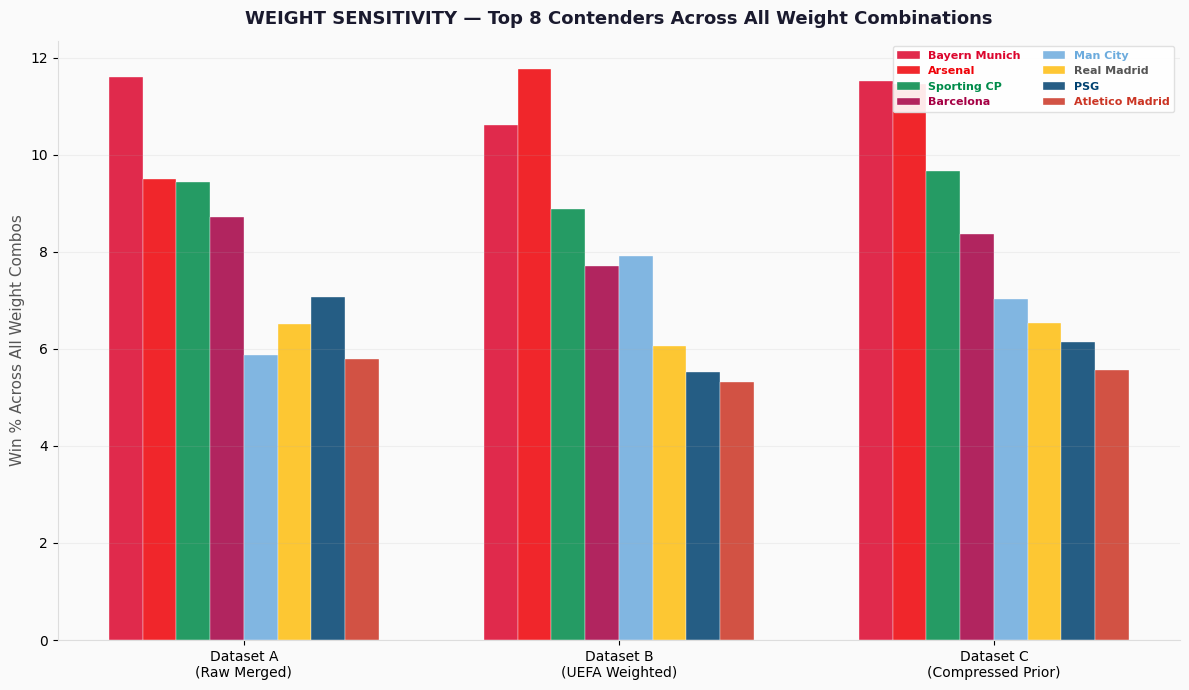

✓ Sensitivity chart complete


In [29]:
# ============================================================
# CHART: SENSITIVITY — TOP 8 ACROSS WEIGHT COMBOS
# ============================================================

top8 = sens_df.head(8).index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x = np.arange(3)
bar_width = 0.09

for j, team in enumerate(top8):
    vals = [sens_df.loc[team, 'A_pct'], sens_df.loc[team, 'B_pct'], sens_df.loc[team, 'C_pct']]
    offset = (j - len(top8)/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, bar_width, color=team_colors[team],
                  alpha=0.85, edgecolor='white', linewidth=0.3, label=team)

ax.set_xticks(x)
ax.set_xticklabels(['Dataset A\n(Raw Merged)', 'Dataset B\n(UEFA Weighted)', 'Dataset C\n(Compressed Prior)'],
                   fontsize=10, fontweight='500')
ax.set_ylabel('Win % Across All Weight Combos', fontsize=11, color='#555')
ax.set_title('WEIGHT SENSITIVITY — Top 8 Contenders Across All Weight Combinations',
            fontsize=13, fontweight='bold', color='#1a1a2e', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ddd')
ax.spines['bottom'].set_color('#ddd')
ax.grid(axis='y', alpha=0.15)

leg = ax.legend(fontsize=8, loc='upper right', ncol=2, framealpha=0.9, edgecolor='#ddd')
for text in leg.get_texts():
    c = team_colors.get(text.get_text(), '#333')
    if c in ['#FFD700', '#FEBE10', '#FFFFFF', '#241F20']:
        c = '#555'
    text.set_color(c)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()
print("✓ Sensitivity chart complete")

In [30]:
# ============================================================
# PHASE 4C — ENSEMBLE STRENGTH + SINGLE CONSENSUS BRACKET
# ============================================================

print("="*80)
print("  ENSEMBLE BRACKET — Averaged Strength Across 3 Datasets")
print("="*80)

# Average strength scores across A, B, C
ensemble_strength = pd.Series(0.0, index=strength['A'].index)
for label in ['A', 'B', 'C']:
    ensemble_strength += strength[label]['Strength']
ensemble_strength = (ensemble_strength / 3).round(4)

print("\n  Ensemble Strength Scores (avg of A, B, C):")
print(f"  {'─'*40}")
for team, val in ensemble_strength.sort_values(ascending=False).items():
    bar = '█' * int(val * 30)
    print(f"  {team:<22s} {val:.4f}  {bar}")

# ── Run 10K simulation with ensemble scores ──
N_ENS = 10_000
np.random.seed(42)

ens_round_counts = {rnd: defaultdict(int) for rnd in ['R16', 'QF', 'SF', 'Final', 'Champion']}
ens_matchup_wins = defaultdict(lambda: defaultdict(int))
s = ensemble_strength

for _ in range(N_ENS):
    r16_w = []
    for ta, tb in bracket_ties['R16']:
        p = win_prob(s[ta], s[tb], k=1.5)
        w = ta if np.random.random() < p else tb
        r16_w.append(w)
        ens_round_counts['R16'][w] += 1
        ens_matchup_wins[(ta, tb)][w] += 1

    qf_w = []
    for ia, ib in bracket_ties['QF_pairs']:
        ta, tb = r16_w[ia], r16_w[ib]
        p = win_prob(s[ta], s[tb], k=1.5)
        w = ta if np.random.random() < p else tb
        qf_w.append(w)
        ens_round_counts['QF'][w] += 1

    sf_w = []
    for ia, ib in bracket_ties['SF_pairs']:
        ta, tb = qf_w[ia], qf_w[ib]
        p = win_prob(s[ta], s[tb], k=1.5)
        w = ta if np.random.random() < p else tb
        sf_w.append(w)
        ens_round_counts['SF'][w] += 1

    ta, tb = sf_w[0], sf_w[1]
    p = win_prob(s[ta], s[tb], k=1.5)
    w = ta if np.random.random() < p else tb
    ens_round_counts['Final'][w] += 1
    ens_round_counts['Champion'][w] += 1

print(f"\n✓ Ensemble simulation complete: {N_ENS:,} runs")

  ENSEMBLE BRACKET — Averaged Strength Across 3 Datasets

  Ensemble Strength Scores (avg of A, B, C):
  ────────────────────────────────────────
  Bayern Munich          0.7472  ██████████████████████
  Arsenal                0.7321  █████████████████████
  Sporting CP            0.6856  ████████████████████
  Man City               0.6166  ██████████████████
  Barcelona              0.6128  ██████████████████
  Real Madrid            0.5930  █████████████████
  PSG                    0.5570  ████████████████
  Chelsea                0.5215  ███████████████
  Liverpool              0.5087  ███████████████
  Atletico Madrid        0.4935  ██████████████
  Galatasaray            0.4917  ██████████████
  FK Bodø/Glimt          0.4528  █████████████
  Atalanta               0.4526  █████████████
  Newcastle              0.4241  ████████████
  Bayer Leverkusen       0.4184  ████████████
  Tottenham              0.3757  ███████████

✓ Ensemble simulation complete: 10,000 runs


In [31]:
# ============================================================
# ENSEMBLE R16 MATCHUPS
# ============================================================

print(f"\n{'='*70}")
print(f"  ENSEMBLE R16 MATCHUP PROBABILITIES")
print(f"{'='*70}")

for ta, tb in bracket_ties['R16']:
    key = (ta, tb)
    wa = ens_matchup_wins[key].get(ta, 0) / N_ENS * 100
    wb = ens_matchup_wins[key].get(tb, 0) / N_ENS * 100

    bar_a = '█' * int(wa / 3)
    bar_b = '█' * int(wb / 3)

    margin = abs(wa - wb)
    tag = '🔥 TIGHT' if margin < 15 else '⚖️ LEAN' if margin < 35 else '💪 CLEAR'

    fav = ta if wa > wb else tb

    print(f"\n  {ta} vs {tb}  [{tag}]")
    print(f"    {ta:>22s}  {wa:5.1f}%  {bar_a}")
    print(f"    {tb:>22s}  {wb:5.1f}%  {bar_b}")
    print(f"    → Favorite: {fav}")


  ENSEMBLE R16 MATCHUP PROBABILITIES

  PSG vs Chelsea  [🔥 TIGHT]
                       PSG   51.2%  █████████████████
                   Chelsea   48.8%  ████████████████
    → Favorite: PSG

  Galatasaray vs Liverpool  [🔥 TIGHT]
               Galatasaray   50.1%  ████████████████
                 Liverpool   49.9%  ████████████████
    → Favorite: Galatasaray

  Real Madrid vs Man City  [🔥 TIGHT]
               Real Madrid   49.1%  ████████████████
                  Man City   50.9%  ████████████████
    → Favorite: Man City

  Atalanta vs Bayern Munich  [⚖️ LEAN]
                  Atalanta   38.3%  ████████████
             Bayern Munich   61.7%  ████████████████████
    → Favorite: Bayern Munich

  Newcastle vs Barcelona  [🔥 TIGHT]
                 Newcastle   43.1%  ██████████████
                 Barcelona   56.9%  ██████████████████
    → Favorite: Barcelona

  Atletico Madrid vs Tottenham  [🔥 TIGHT]
           Atletico Madrid   53.6%  █████████████████
                 Totte

In [32]:
# ============================================================
# ENSEMBLE ADVANCEMENT TABLE
# ============================================================

print(f"\n{'='*80}")
print(f"  ENSEMBLE ROUND-BY-ROUND ADVANCEMENT ({N_ENS:,} sims)")
print(f"{'='*80}")
print(f"  {'Team':<22s} {'R16 Win':>8s} {'QF Win':>8s} {'SF Win':>8s} {'Champion':>9s}")
print(f"  {'─'*56}")

all_sorted = sorted(team_colors.keys(),
                    key=lambda t: ens_round_counts['Champion'].get(t, 0), reverse=True)

for team in all_sorted:
    r16 = ens_round_counts['R16'].get(team, 0) / N_ENS * 100
    qf  = ens_round_counts['QF'].get(team, 0) / N_ENS * 100
    sf  = ens_round_counts['SF'].get(team, 0) / N_ENS * 100
    chp = ens_round_counts['Champion'].get(team, 0) / N_ENS * 100
    print(f"  {team:<22s} {r16:>7.1f}% {qf:>7.1f}% {sf:>7.1f}% {chp:>8.1f}%")


  ENSEMBLE ROUND-BY-ROUND ADVANCEMENT (10,000 sims)
  Team                    R16 Win   QF Win   SF Win  Champion
  ────────────────────────────────────────────────────────
  Bayern Munich             61.7%    33.9%    20.2%     11.2%
  Arsenal                   62.2%    34.2%    19.8%     10.9%
  Sporting CP               58.5%    31.1%    17.9%      9.5%
  Barcelona                 56.9%    32.0%    16.1%      8.5%
  Man City                  50.9%    25.0%    13.3%      6.9%
  Real Madrid               49.1%    24.0%    12.7%      6.5%
  PSG                       51.2%    26.7%    12.5%      6.1%
  Atletico Madrid           53.6%    26.1%    12.0%      5.8%
  Chelsea                   48.8%    24.6%    11.2%      5.7%
  Liverpool                 49.9%    24.7%    11.5%      5.5%
  Galatasaray               50.1%    24.0%    10.7%      5.2%
  FK Bodø/Glimt             41.5%    18.2%     8.9%      4.1%
  Newcastle                 43.1%    21.4%     9.2%      4.0%
  Bayer Leverkusen  

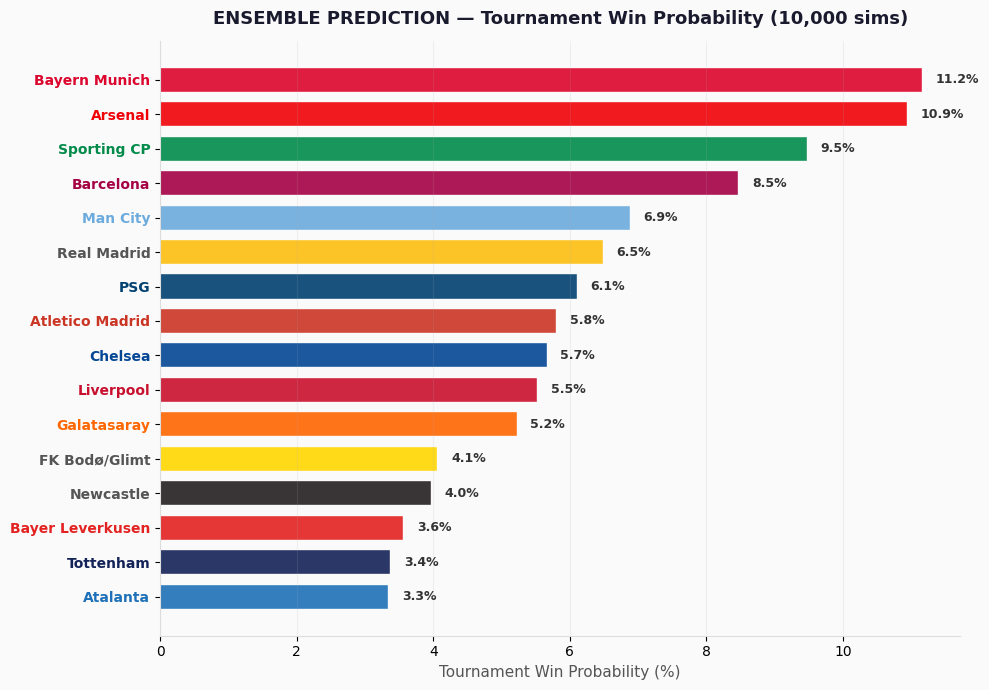

In [33]:
# ============================================================
# ENSEMBLE TOURNAMENT WIN CHART
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

data = {}
for team in team_colors.keys():
    data[team] = ens_round_counts['Champion'].get(team, 0) / N_ENS * 100

sorted_teams = sorted(data.keys(), key=lambda t: data[t])
vals = [data[t] for t in sorted_teams]
colors = [team_colors[t] for t in sorted_teams]

bars = ax.barh(range(len(sorted_teams)), vals, color=colors, alpha=0.9,
               height=0.7, edgecolor='white', linewidth=0.3)

ax.set_yticks(range(len(sorted_teams)))
ax.set_yticklabels(sorted_teams, fontsize=10, fontweight='600')

for tick, team in zip(ax.get_yticklabels(), sorted_teams):
    c = team_colors[team]
    if c in ['#FFD700', '#FEBE10', '#FFFFFF', '#241F20']:
        c = '#555'
    tick.set_color(c)

for j, (val, bar) in enumerate(zip(vals, bars)):
    if val > 0.3:
        ax.text(val + 0.2, j, f'{val:.1f}%', va='center', fontsize=9,
               fontweight='bold', color='#333')

ax.set_xlabel('Tournament Win Probability (%)', fontsize=11, color='#555')
ax.set_title(f'ENSEMBLE PREDICTION — Tournament Win Probability ({N_ENS:,} sims)',
            fontsize=13, fontweight='bold', color='#1a1a2e', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ddd')
ax.spines['bottom'].set_color('#ddd')
ax.grid(axis='x', alpha=0.15)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# FINAL PREDICTION TABLE — Everything Combined
# ============================================================

print("="*80)
print("  🏆 FINAL PREDICTION TABLE — ALL METHODS COMBINED")
print("="*80)

final = {}
for team in team_colors.keys():
    ds_a = sim_results['A']['Champion'].get(team, 0) / N_SIMS * 100
    ds_b = sim_results['B']['Champion'].get(team, 0) / N_SIMS * 100
    ds_c = sim_results['C']['Champion'].get(team, 0) / N_SIMS * 100
    ens  = ens_round_counts['Champion'].get(team, 0) / N_ENS * 100
    sens_pct = sens_df.loc[team, 'total_pct'] if team in sens_df.index else 0

    # Weighted final score: ensemble 40%, sensitivity 30%, avg(A,B,C) 30%
    avg_abc = np.mean([ds_a, ds_b, ds_c])
    final_score = 0.40 * ens + 0.30 * sens_pct + 0.30 * avg_abc

    final[team] = {
        'DS_A': ds_a, 'DS_B': ds_b, 'DS_C': ds_c,
        'Ensemble': ens, 'Sensitivity': sens_pct,
        'Final_Score': round(final_score, 2)
    }

final_df = pd.DataFrame(final).T.sort_values('Final_Score', ascending=False)

print(f"\n  {'Team':<22s} {'DS_A':>6s} {'DS_B':>6s} {'DS_C':>6s} {'Ensem':>6s} {'Sens':>6s} {'FINAL':>7s}")
print(f"  {'─'*62}")
for i, (team, row) in enumerate(final_df.iterrows()):
    medal = ['🥇','🥈','🥉'][i] if i < 3 else '  '
    print(f"{medal}{team:<22s} {row['DS_A']:5.1f}% {row['DS_B']:5.1f}% {row['DS_C']:5.1f}% "
          f"{row['Ensemble']:5.1f}% {row['Sensitivity']:5.1f}% {row['Final_Score']:6.1f}%")

print(f"""
  ──────────────────────────────────────────────────────────────
  SCORING: Final = 40% × Ensemble + 30% × Sensitivity + 30% × Avg(A,B,C)

  • Ensemble: averaged strength across 3 datasets → single bracket sim
  • Sensitivity: win % across ALL weight combos (stress test)
  • Avg(A,B,C): mean of the 3 individual dataset simulations
  ──────────────────────────────────────────────────────────────""")

# ── THE CALL ──
champ = final_df.index[0]
champ_score = final_df.iloc[0]['Final_Score']
runner = final_df.index[1]
runner_score = final_df.iloc[1]['Final_Score']
third = final_df.index[2]
third_score = final_df.iloc[2]['Final_Score']

print(f"""
  ╔══════════════════════════════════════════════════════════════╗
  ║                                                              ║
  ║   🏆  PREDICTED UCL CHAMPION: {champ:<20s}  ({champ_score:.1f}%)    ║
  ║   🥈  Runner-up:              {runner:<20s}  ({runner_score:.1f}%)    ║
  ║   🥉  Third:                  {third:<20s}  ({third_score:.1f}%)    ║
  ║                                                              ║
  ╚══════════════════════════════════════════════════════════════╝
""")

  🏆 FINAL PREDICTION TABLE — ALL METHODS COMBINED

  Team                     DS_A   DS_B   DS_C  Ensem   Sens   FINAL
  ──────────────────────────────────────────────────────────────
🥇Bayern Munich           11.5%  10.5%  10.5%  11.2%  11.2%   11.1%
🥈Arsenal                  9.5%  12.0%  11.9%  10.9%  10.9%   11.0%
🥉Sporting CP              9.2%   8.8%   9.9%   9.5%   9.3%    9.4%
  Barcelona                8.9%   7.6%   8.6%   8.5%   8.3%    8.4%
  Man City                 5.7%   7.6%   6.9%   6.9%   6.9%    6.8%
  Real Madrid              6.7%   6.6%   6.1%   6.5%   6.4%    6.4%
  PSG                      6.9%   5.0%   6.1%   6.1%   6.2%    6.1%
  Atletico Madrid          6.0%   5.7%   5.6%   5.8%   5.6%    5.7%
  Chelsea                  4.6%   6.9%   5.4%   5.7%   5.5%    5.6%
  Liverpool                4.2%   6.5%   5.1%   5.5%   5.5%    5.4%
  Galatasaray              7.8%   3.5%   5.4%   5.2%   5.2%    5.3%
  FK Bodø/Glimt            6.1%   2.6%   4.4%   4.1%   4.2%    4.2%
  N

FINAL

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# ============================================================
# PHASE 4 — BRACKET WALKTHROUGH (KNOCKOUT FORMAT)
# ============================================================

# Ensure all variables are available
team_colors = {
    'Arsenal': '#EF0107', 'Man City': '#6CABDD', 'Chelsea': '#034694',
    'Liverpool': '#C8102E', 'Newcastle': '#241F20', 'Tottenham': '#132257',
    'Barcelona': '#A50044', 'Real Madrid': '#FEBE10', 'Atletico Madrid': '#CB3524',
    'Atalanta': '#1E71B8', 'Galatasaray': '#FF6600', 'Bayern Munich': '#DC052D',
    'Bayer Leverkusen': '#E32221', 'FK Bodø/Glimt': '#FFD700',
    'Sporting CP': '#008B4A', 'PSG': '#004170',
}

names = {'A': 'Raw Merged', 'B': 'UEFA Weighted', 'C': 'Compressed Prior'}
N_SIMS = 10_000

bracket_ties = {
    'R16': [
        ('PSG', 'Chelsea'),
        ('Galatasaray', 'Liverpool'),
        ('Real Madrid', 'Man City'),
        ('Atalanta', 'Bayern Munich'),
        ('Newcastle', 'Barcelona'),
        ('Atletico Madrid', 'Tottenham'),
        ('FK Bodø/Glimt', 'Sporting CP'),
        ('Bayer Leverkusen', 'Arsenal'),
    ],
    'QF_pairs': [(0,1), (2,3), (4,5), (6,7)],
    'SF_pairs': [(0,1), (2,3)],
}

def win_prob(s_a, s_b, k=1.5):
    return 1 / (1 + np.exp(-k * (s_a - s_b)))

# ── Ensemble strength (avg of A, B, C) ──
ensemble_strength = pd.Series(0.0, index=strength['A'].index)
for label in ['A', 'B', 'C']:
    ensemble_strength += strength[label]['Strength']
ensemble_strength = (ensemble_strength / 3).round(4)

# ============================================================
# SIMULATE BRACKET — Track every matchup at every round
# ============================================================
np.random.seed(42)

# Storage: for each possible matchup at each round, track win counts
round_matchup_tracker = {
    'R16': defaultdict(lambda: defaultdict(int)),
    'QF':  defaultdict(lambda: defaultdict(int)),
    'SF':  defaultdict(lambda: defaultdict(int)),
    'Final': defaultdict(lambda: defaultdict(int)),
}
round_appearance = {
    'QF': defaultdict(int),
    'SF': defaultdict(int),
    'Final': defaultdict(int),
}
champion_count = defaultdict(int)

s = ensemble_strength

for _ in range(N_SIMS):
    # R16
    r16_w = []
    for ta, tb in bracket_ties['R16']:
        p = win_prob(s[ta], s[tb], k=1.5)
        w = ta if np.random.random() < p else tb
        r16_w.append(w)
        key = tuple(sorted([ta, tb]))
        round_matchup_tracker['R16'][key][w] += 1

    # QF
    qf_w = []
    for ia, ib in bracket_ties['QF_pairs']:
        ta, tb = r16_w[ia], r16_w[ib]
        round_appearance['QF'][ta] += 1
        round_appearance['QF'][tb] += 1
        p = win_prob(s[ta], s[tb], k=1.5)
        w = ta if np.random.random() < p else tb
        qf_w.append(w)
        key = tuple(sorted([ta, tb]))
        round_matchup_tracker['QF'][key][w] += 1

    # SF
    sf_w = []
    for ia, ib in bracket_ties['SF_pairs']:
        ta, tb = qf_w[ia], qf_w[ib]
        round_appearance['SF'][ta] += 1
        round_appearance['SF'][tb] += 1
        p = win_prob(s[ta], s[tb], k=1.5)
        w = ta if np.random.random() < p else tb
        sf_w.append(w)
        key = tuple(sorted([ta, tb]))
        round_matchup_tracker['SF'][key][w] += 1

    # Final
    ta, tb = sf_w[0], sf_w[1]
    round_appearance['Final'][ta] += 1
    round_appearance['Final'][tb] += 1
    p = win_prob(s[ta], s[tb], k=1.5)
    w = ta if np.random.random() < p else tb
    key = tuple(sorted([ta, tb]))
    round_matchup_tracker['Final'][key][w] += 1
    champion_count[w] += 1

print(f"✓ Ensemble bracket simulation: {N_SIMS:,} runs complete")
print(f"  Tracking every matchup at every round")

✓ Ensemble bracket simulation: 10,000 runs complete
  Tracking every matchup at every round


In [36]:
# ============================================================
# ROUND OF 16 — Fixed matchups, who advances?
# ============================================================

print("="*75)
print("  🏟️  ROUND OF 16 — Who Advances?")
print("="*75)

r16_winners_most_likely = []

for ta, tb in bracket_ties['R16']:
    key = tuple(sorted([ta, tb]))
    wins_a = round_matchup_tracker['R16'][key].get(ta, 0)
    wins_b = round_matchup_tracker['R16'][key].get(tb, 0)
    total = wins_a + wins_b
    pct_a = wins_a / total * 100
    pct_b = wins_b / total * 100

    fav = ta if pct_a > pct_b else tb
    fav_pct = max(pct_a, pct_b)
    dog = tb if fav == ta else ta
    dog_pct = min(pct_a, pct_b)

    r16_winners_most_likely.append(fav)

    margin = abs(pct_a - pct_b)
    tag = '🔥 TIGHT' if margin < 15 else '⚖️ LEAN' if margin < 35 else '💪 CLEAR'

    bar_a = '█' * int(pct_a / 4)
    bar_b = '█' * int(pct_b / 4)

    print(f"\n  ┌─────────────────────────────────────────────────────────┐")
    print(f"  │  {ta:>22s}  {pct_a:5.1f}%  {bar_a}")
    print(f"  │  {'vs':>22s}                              {tag}")
    print(f"  │  {tb:>22s}  {pct_b:5.1f}%  {bar_b}")
    print(f"  │  ➤ ADVANCES: {fav} ({fav_pct:.1f}%)")
    print(f"  └─────────────────────────────────────────────────────────┘")

print(f"\n  R16 Winners → QF:")
for i, w in enumerate(r16_winners_most_likely):
    print(f"    Slot {i+1}: {w}")

  🏟️  ROUND OF 16 — Who Advances?

  ┌─────────────────────────────────────────────────────────┐
  │                     PSG   51.2%  ████████████
  │                      vs                              🔥 TIGHT
  │                 Chelsea   48.8%  ████████████
  │  ➤ ADVANCES: PSG (51.2%)
  └─────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────┐
  │             Galatasaray   50.1%  ████████████
  │                      vs                              🔥 TIGHT
  │               Liverpool   49.9%  ████████████
  │  ➤ ADVANCES: Galatasaray (50.1%)
  └─────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────┐
  │             Real Madrid   49.1%  ████████████
  │                      vs                              🔥 TIGHT
  │                Man City   50.9%  ████████████
  │  ➤ ADVANCES: Man City (50.9%)
  └───────────────────────────────────────────────────────

In [37]:
# ============================================================
# QUARTER-FINALS — Who do they face? Who advances?
# ============================================================

print("="*75)
print("  ⚔️  QUARTER-FINALS — Matchups & Predictions")
print("="*75)

# QF matchups are determined by R16 bracket slots
qf_slots = [(0,1), (2,3), (4,5), (6,7)]
qf_labels = [
    'QF1: R16-1 Winner vs R16-2 Winner',
    'QF2: R16-3 Winner vs R16-4 Winner',
    'QF3: R16-5 Winner vs R16-6 Winner',
    'QF4: R16-7 Winner vs R16-8 Winner',
]

# Show most common QF matchups and their outcomes
print("\n  Most likely QF matchups (from simulation):\n")

qf_winners_likely = []

for qi, (ia, ib) in enumerate(qf_slots):
    # Find the most common matchup for this QF slot
    qf_matchups_here = defaultdict(int)
    # We need to re-examine — let's find the top matchups from tracker

    # The most likely matchup is the predicted R16 winners
    likely_a = r16_winners_most_likely[ia]
    likely_b = r16_winners_most_likely[ib]

    key = tuple(sorted([likely_a, likely_b]))
    wins_a = round_matchup_tracker['QF'][key].get(likely_a, 0)
    wins_b = round_matchup_tracker['QF'][key].get(likely_b, 0)
    total = wins_a + wins_b

    if total > 0:
        pct_a = wins_a / total * 100
        pct_b = wins_b / total * 100
    else:
        pct_a = pct_b = 50.0

    # How often does this exact matchup happen?
    matchup_freq = total / N_SIMS * 100

    fav = likely_a if pct_a > pct_b else likely_b
    fav_pct = max(pct_a, pct_b)
    qf_winners_likely.append(fav)

    margin = abs(pct_a - pct_b)
    tag = '🔥 TIGHT' if margin < 15 else '⚖️ LEAN' if margin < 35 else '💪 CLEAR'

    bar_a = '█' * int(pct_a / 4)
    bar_b = '█' * int(pct_b / 4)

    # Also show alternative opponents
    r16_tie_a = bracket_ties['R16'][ia]
    r16_tie_b = bracket_ties['R16'][ib]
    alt_a = r16_tie_a[1] if r16_tie_a[0] == likely_a else r16_tie_a[0]
    alt_b = r16_tie_b[1] if r16_tie_b[0] == likely_b else r16_tie_b[0]

    print(f"  ┌─────────────────────────────────────────────────────────────┐")
    print(f"  │  QF{qi+1}  (this matchup occurs in {matchup_freq:.0f}% of sims)")
    print(f"  │  {likely_a:>22s}  {pct_a:5.1f}%  {bar_a}")
    print(f"  │  {'vs':>22s}                                 {tag}")
    print(f"  │  {likely_b:>22s}  {pct_b:5.1f}%  {bar_b}")
    print(f"  │  ➤ ADVANCES: {fav} ({fav_pct:.1f}%)")
    print(f"  │  (Alt opponents: {alt_a} or {alt_b} if R16 upsets)")
    print(f"  └─────────────────────────────────────────────────────────────┘")
    print()

  ⚔️  QUARTER-FINALS — Matchups & Predictions

  Most likely QF matchups (from simulation):

  ┌─────────────────────────────────────────────────────────────┐
  │  QF1  (this matchup occurs in 26% of sims)
  │                     PSG   53.0%  █████████████
  │                      vs                                 🔥 TIGHT
  │             Galatasaray   47.0%  ███████████
  │  ➤ ADVANCES: PSG (53.0%)
  │  (Alt opponents: Chelsea or Liverpool if R16 upsets)
  └─────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────┐
  │  QF2  (this matchup occurs in 31% of sims)
  │                Man City   44.7%  ███████████
  │                      vs                                 🔥 TIGHT
  │           Bayern Munich   55.3%  █████████████
  │  ➤ ADVANCES: Bayern Munich (55.3%)
  │  (Alt opponents: Real Madrid or Atalanta if R16 upsets)
  └─────────────────────────────────────────────────────────────┘

  ┌───────────────────────

In [38]:
# ============================================================
# SEMI-FINALS — Matchups & Predictions
# ============================================================

print("="*75)
print("  🔥 SEMI-FINALS — Matchups & Predictions")
print("="*75)

sf_slots = [(0,1), (2,3)]
sf_winners_likely = []

for si, (qa, qb) in enumerate(sf_slots):
    likely_a = qf_winners_likely[qa]
    likely_b = qf_winners_likely[qb]

    key = tuple(sorted([likely_a, likely_b]))
    wins_a = round_matchup_tracker['SF'][key].get(likely_a, 0)
    wins_b = round_matchup_tracker['SF'][key].get(likely_b, 0)
    total = wins_a + wins_b

    if total > 0:
        pct_a = wins_a / total * 100
        pct_b = wins_b / total * 100
    else:
        pct_a = pct_b = 50.0

    matchup_freq = total / N_SIMS * 100

    fav = likely_a if pct_a > pct_b else likely_b
    fav_pct = max(pct_a, pct_b)
    sf_winners_likely.append(fav)

    margin = abs(pct_a - pct_b)
    tag = '🔥 TIGHT' if margin < 15 else '⚖️ LEAN' if margin < 35 else '💪 CLEAR'

    bar_a = '█' * int(pct_a / 4)
    bar_b = '█' * int(pct_b / 4)

    print(f"\n  ┌─────────────────────────────────────────────────────────────┐")
    print(f"  │  SF{si+1}  (this matchup occurs in {matchup_freq:.0f}% of sims)")
    print(f"  │  {likely_a:>22s}  {pct_a:5.1f}%  {bar_a}")
    print(f"  │  {'vs':>22s}                                 {tag}")
    print(f"  │  {likely_b:>22s}  {pct_b:5.1f}%  {bar_b}")
    print(f"  │  ➤ ADVANCES TO FINAL: {fav} ({fav_pct:.1f}%)")
    print(f"  └─────────────────────────────────────────────────────────────┘")

  🔥 SEMI-FINALS — Matchups & Predictions

  ┌─────────────────────────────────────────────────────────────┐
  │  SF1  (this matchup occurs in 9% of sims)
  │                     PSG   43.9%  ██████████
  │                      vs                                 🔥 TIGHT
  │           Bayern Munich   56.1%  ██████████████
  │  ➤ ADVANCES TO FINAL: Bayern Munich (56.1%)
  └─────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────┐
  │  SF2  (this matchup occurs in 11% of sims)
  │               Barcelona   44.9%  ███████████
  │                      vs                                 🔥 TIGHT
  │                 Arsenal   55.1%  █████████████
  │  ➤ ADVANCES TO FINAL: Arsenal (55.1%)
  └─────────────────────────────────────────────────────────────┘


In [39]:
# ============================================================
# THE FINAL
# ============================================================

print("="*75)
print("  🏆 THE FINAL")
print("="*75)

fa, fb = sf_winners_likely[0], sf_winners_likely[1]
key = tuple(sorted([fa, fb]))
wins_a = round_matchup_tracker['Final'][key].get(fa, 0)
wins_b = round_matchup_tracker['Final'][key].get(fb, 0)
total = wins_a + wins_b

if total > 0:
    pct_a = wins_a / total * 100
    pct_b = wins_b / total * 100
else:
    pct_a = pct_b = 50.0

matchup_freq = total / N_SIMS * 100
champ = fa if pct_a > pct_b else fb
champ_pct = max(pct_a, pct_b)
runner = fb if champ == fa else fa
runner_pct = min(pct_a, pct_b)

bar_a = '█' * int(pct_a / 3)
bar_b = '█' * int(pct_b / 3)

print(f"\n  ┌═══════════════════════════════════════════════════════════════┐")
print(f"  ║  THE FINAL  (this matchup occurs in {matchup_freq:.0f}% of sims)")
print(f"  ║")
print(f"  ║  {fa:>22s}  {pct_a:5.1f}%  {bar_a}")
print(f"  ║  {'vs':>22s}")
print(f"  ║  {fb:>22s}  {pct_b:5.1f}%  {bar_b}")
print(f"  ║")
print(f"  ║  🏆 PREDICTED CHAMPION: {champ} ({champ_pct:.1f}%)")
print(f"  ╚═══════════════════════════════════════════════════════════════╝")

  🏆 THE FINAL

  ┌═══════════════════════════════════════════════════════════════┐
  ║  THE FINAL  (this matchup occurs in 4% of sims)
  ║
  ║           Bayern Munich   47.7%  ███████████████
  ║                      vs
  ║                 Arsenal   52.3%  █████████████████
  ║
  ║  🏆 PREDICTED CHAMPION: Arsenal (52.3%)
  ╚═══════════════════════════════════════════════════════════════╝


In [40]:
# ============================================================
# FULL PREDICTED BRACKET — Visual Summary
# ============================================================

print("\n" + "="*80)
print("  📋 PREDICTED BRACKET — MOST LIKELY PATH")
print("="*80)

# R16 results
r16 = bracket_ties['R16']
r16w = r16_winners_most_likely
qfw = qf_winners_likely
sfw = sf_winners_likely

def short(name):
    mapping = {
        'FK Bodø/Glimt': 'Bodø/Glimt', 'Bayer Leverkusen': 'Leverkusen',
        'Atletico Madrid': 'Atlético', 'Bayern Munich': 'Bayern',
    }
    return mapping.get(name, name)

print(f"""
  ROUND OF 16                QUARTER-FINALS         SEMI-FINALS           FINAL
  ═══════════════════════════════════════════════════════════════════════════════

  {short(r16[0][0]):>16s} ─┐
                     ├─ {short(r16w[0]):<16s} ─┐
  {short(r16[0][1]):>16s} ─┘                    │
                                        ├─ {short(qfw[0]):<16s} ─┐
  {short(r16[1][0]):>16s} ─┐                    │                    │
                     ├─ {short(r16w[1]):<16s} ─┘                    │
  {short(r16[1][1]):>16s} ─┘                                        │
                                                                ├─ {short(sfw[0]):<14s} ─┐
  {short(r16[2][0]):>16s} ─┐                                        │                    │
                     ├─ {short(r16w[2]):<16s} ─┐                    │                    │
  {short(r16[2][1]):>16s} ─┘                    │                    │                    │
                                        ├─ {short(qfw[1]):<16s} ─┘                    │
  {short(r16[3][0]):>16s} ─┐                    │                                        │
                     ├─ {short(r16w[3]):<16s} ─┘                                        │
  {short(r16[3][1]):>16s} ─┘                                                             │
                                                                                     🏆 {short(champ)}
  {short(r16[4][0]):>16s} ─┐                                                             │
                     ├─ {short(r16w[4]):<16s} ─┐                                        │
  {short(r16[4][1]):>16s} ─┘                    │                                        │
                                        ├─ {short(qfw[2]):<16s} ─┐                    │
  {short(r16[5][0]):>16s} ─┐                    │                    │                    │
                     ├─ {short(r16w[5]):<16s} ─┘                    │                    │
  {short(r16[5][1]):>16s} ─┘                                        │                    │
                                                                ├─ {short(sfw[1]):<14s} ─┘
  {short(r16[6][0]):>16s} ─┐                                        │
                     ├─ {short(r16w[6]):<16s} ─┐                    │
  {short(r16[6][1]):>16s} ─┘                    │                    │
                                        ├─ {short(qfw[3]):<16s} ─┘
  {short(r16[7][0]):>16s} ─┐                    │
                     ├─ {short(r16w[7]):<16s} ─┘
  {short(r16[7][1]):>16s} ─┘
""")

print("="*80)
print(f"  🏆 {champ} WINS THE CHAMPIONS LEAGUE")
print("="*80)


  📋 PREDICTED BRACKET — MOST LIKELY PATH

  ROUND OF 16                QUARTER-FINALS         SEMI-FINALS           FINAL
  ═══════════════════════════════════════════════════════════════════════════════

               PSG ─┐
                     ├─ PSG              ─┐
           Chelsea ─┘                    │
                                        ├─ PSG              ─┐
       Galatasaray ─┐                    │                    │
                     ├─ Galatasaray      ─┘                    │
         Liverpool ─┘                                        │
                                                                ├─ Bayern         ─┐
       Real Madrid ─┐                                        │                    │
                     ├─ Man City         ─┐                    │                    │
          Man City ─┘                    │                    │                    │
                                        ├─ Bayern           ─┘                    │
      

In [45]:
# ============================================================
# UPSET TRACKER — Most likely upsets at each round
# ============================================================

print("="*75)
print("  ⚡ UPSET WATCH — Where the bracket could break")
print("="*75)

print("\n  R16 ties most likely to produce an upset:")
print(f"  {'─'*60}")

r16_margins = []
for ta, tb in bracket_ties['R16']:
    key = tuple(sorted([ta, tb]))
    wa = round_matchup_tracker['R16'][key].get(ta, 0)
    wb = round_matchup_tracker['R16'][key].get(tb, 0)
    total = wa + wb
    pct_a = wa / total * 100
    pct_b = wb / total * 100
    margin = abs(pct_a - pct_b)
    fav = ta if pct_a > pct_b else tb
    dog = tb if fav == ta else ta
    dog_pct = min(pct_a, pct_b)
    r16_margins.append((margin, ta, tb, fav, dog, dog_pct))

r16_margins.sort(key=lambda x: x[0])

for margin, ta, tb, fav, dog, dog_pct in r16_margins:
    alert = '🔴' if margin < 10 else '🟡' if margin < 20 else '🟢'
    print(f"  {alert} {ta} vs {tb}")
    print(f"     Margin: {margin:.1f}%  |  Underdog: {dog} ({dog_pct:.1f}% chance)")
    print()

print(f"  🔴 = Coin flip (<10%)  🟡 = Upset possible (<20%)  🟢 = Favorite clear (>20%)")

# ── Alternative champions if key upsets happen ──
print(f"\n{'='*75}")
print("  🔄 ALTERNATIVE PATHS — Top 5 most likely champions overall")
print(f"{'='*75}")

champ_sorted = sorted(champion_count.items(), key=lambda x: -x[1])
for i, (team, count) in enumerate(champ_sorted[:5]):
    pct = count / N_SIMS * 100
    medal = ['🥇','🥈','🥉','4️⃣','5️⃣'][i]
    bar = '█' * int(pct / 2)
    print(f"  {medal} {team:<22s} {pct:5.1f}%  {bar}")

  ⚡ UPSET WATCH — Where the bracket could break

  R16 ties most likely to produce an upset:
  ────────────────────────────────────────────────────────────
  🔴 Galatasaray vs Liverpool
     Margin: 0.1%  |  Underdog: Liverpool (49.9% chance)

  🔴 Real Madrid vs Man City
     Margin: 1.8%  |  Underdog: Real Madrid (49.1% chance)

  🔴 PSG vs Chelsea
     Margin: 2.5%  |  Underdog: Chelsea (48.8% chance)

  🔴 Atletico Madrid vs Tottenham
     Margin: 7.1%  |  Underdog: Tottenham (46.4% chance)

  🟡 Newcastle vs Barcelona
     Margin: 13.8%  |  Underdog: Newcastle (43.1% chance)

  🟡 FK Bodø/Glimt vs Sporting CP
     Margin: 17.0%  |  Underdog: FK Bodø/Glimt (41.5% chance)

  🟢 Atalanta vs Bayern Munich
     Margin: 23.3%  |  Underdog: Atalanta (38.3% chance)

  🟢 Bayer Leverkusen vs Arsenal
     Margin: 24.4%  |  Underdog: Bayer Leverkusen (37.8% chance)

  🔴 = Coin flip (<10%)  🟡 = Upset possible (<20%)  🟢 = Favorite clear (>20%)

  🔄 ALTERNATIVE PATHS — Top 5 most likely champions overa